In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
# from matplotlib import style
# style.available

## wp

In [2]:
%%time
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.048975
ns     = 0.9665
mnu    = 0.06
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.50

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=True)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
# Set HOD parameters (Zheng+2005 model)
print("\nSetting HOD parameters...")
param_dict = {'logMcut': 12.88504333, 
              'logM1': 13.89309923, 
              'sigma': 0.21378519, 
              'alpha': 0.99114528, 
              'kappa': 0.5, 
              'fic': 1.0}
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "xihm"
# Compute galaxy properties at z=0.5
z = redshift
print(f"\nGalaxy properties at z={z}:")
print(f"  n_gal    = {emu.ngal(z):.4e} h^3/Mpc^3")
print(f"  f_sat    = {emu.f_sat(z):.3f}")
print(f"  M_eff    = {emu.M_eff(z):.3e} Msun/h")
print(f"  bias_gal = {emu.bias_gal(z):.3f}")

rbins  = np.logspace(-1, np.log10(50), 16)
rmid   = (rbins[1:] + rbins[:-1]) / 2

%time wp_emu1 = emu.wp(rp=rmid, z=z, pimax=None)
%time ds_emu1 = emu.DeltaSigma(rmid, z=z)

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [3]:
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=False)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)
emu._galaxy_calc.satellite_profile.profile_type = "nfw"
# Compute galaxy properties at z=0.5
z = redshift
print(f"\nGalaxy properties at z={z}:")
print(f"  n_gal    = {emu.ngal(z):.4e} h^3/Mpc^3")
print(f"  f_sat    = {emu.f_sat(z):.3f}")
print(f"  M_eff    = {emu.M_eff(z):.3e} Msun/h")
print(f"  bias_gal = {emu.bias_gal(z):.3f}")

rbins  = np.logspace(-1, np.log10(50), 16)
rmid   = (rbins[1:] + rbins[:-1]) / 2

%time wp_emu2 = emu.wp(rp=rmid, z=z, pimax=100.0)
%time ds_emu2 = emu.DeltaSigma(rmid, z=z)


Galaxy properties at z=0.5:
  n_gal    = 7.0778e-04 h^3/Mpc^3
  f_sat    = 0.177
  M_eff    = 3.031e+13 Msun/h
  bias_gal = 1.865
CPU times: user 194 ms, sys: 44.1 ms, total: 238 ms
Wall time: 247 ms
CPU times: user 6.87 ms, sys: 3.21 ms, total: 10.1 ms
Wall time: 10.8 ms


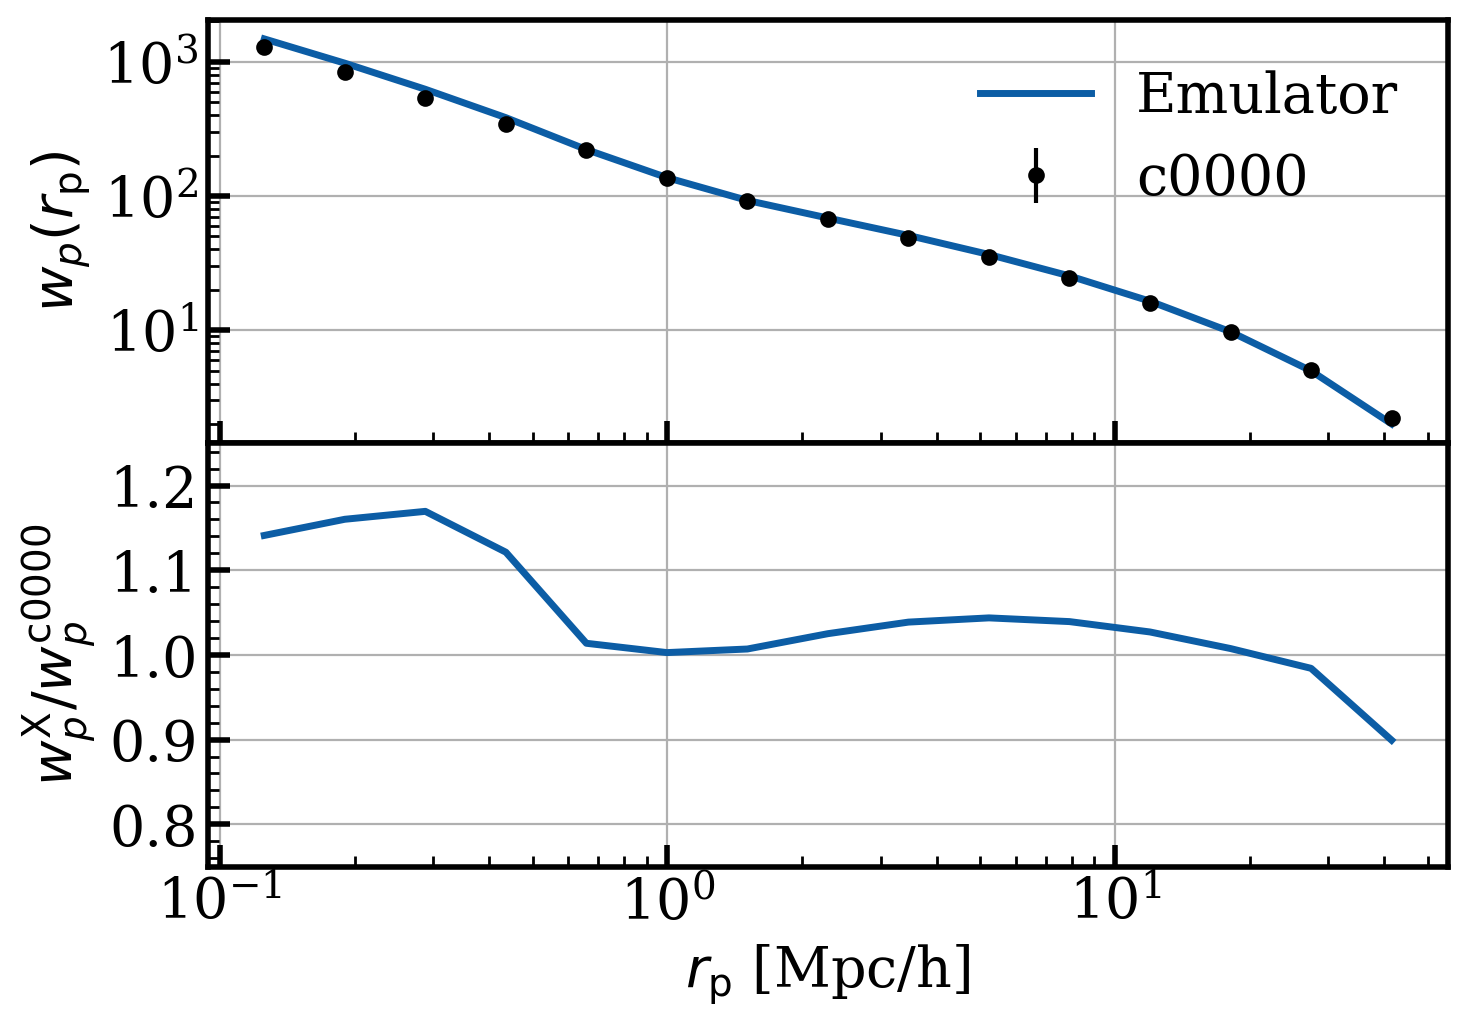

In [12]:
wp_rlz = np.zeros((16, 15))
for iseed in range(16):
    wp_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/wp-galaxy-c0000-1e12-Zheng07+fic-hod2-norsd-seed%d_M200b.npy"%(iseed))
std_wp  = np.std (wp_rlz, axis=0)
mean_wp = np.mean(wp_rlz, axis=0)
with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, wp_emu1, label="Emulator")
    # plt.plot(rmid, wp_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_wp, std_wp, lw=1.5, fmt='ko', label='c0000', markersize=5)
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$w_p(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.plot(rmid, wp_emu1/mean_wp, label="Emulator")
    # plt.plot(rmid, wp_emu2/mean_wp, label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    plt.ylim([0.75, 1.25])
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$w_p^\mathrm{X}/w_p^\mathrm{c0000}$")

CPU times: user 7.3 ms, sys: 1.48 ms, total: 8.77 ms
Wall time: 8.39 ms
CPU times: user 8.74 ms, sys: 842 µs, total: 9.59 ms
Wall time: 11.4 ms
CPU times: user 1.66 ms, sys: 381 µs, total: 2.04 ms
Wall time: 2.8 ms


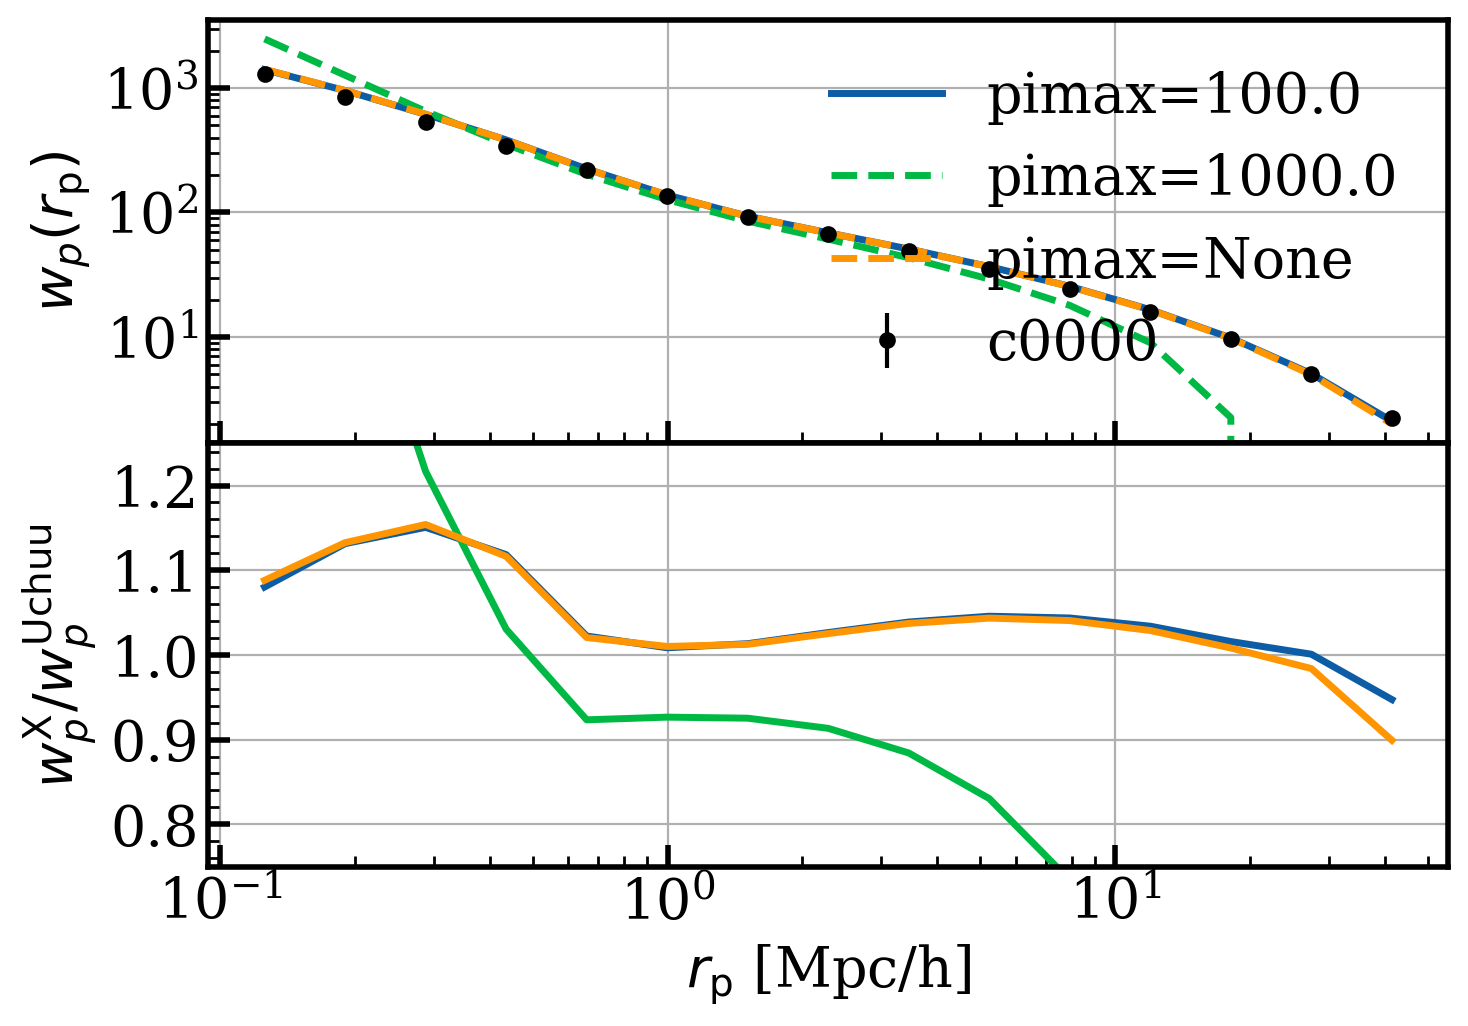

In [9]:
emu._galaxy_calc.satellite_profile.profile_type = "xihm"
%time wp_emu3 = emu.wp(rp=rmid, z=z, pimax=100.0)
%time wp_emu4 = emu.wp(rp=rmid, z=z, pimax=1000.0)
%time wp_emu5 = emu.wp(rp=rmid, z=z, pimax=None)

wp_rlz = np.zeros((16, 15))
for iseed in range(16):
    wp_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/wp-galaxy-c0000-1e12-Zheng07+fic-hod2-norsd-seed%d_M200b.npy"%(iseed))
std_wp  = np.std (wp_rlz, axis=0)
mean_wp = np.mean(wp_rlz, axis=0)

with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, wp_emu3, label="pimax=100.0")
    plt.plot(rmid, wp_emu4, '--', label ="pimax=1000.0")
    plt.plot(rmid, wp_emu5, '--', label ="pimax=None") 
    plt.errorbar(rmid, mean_wp, std_wp, lw=1.5, fmt='ko', label='c0000', markersize=5)
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$w_p(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.plot(rmid, wp_emu3/mean_wp, label="pimax=100.0")
    plt.plot(rmid, wp_emu4/mean_wp, label="pimax=1000.0")
    plt.plot(rmid, wp_emu5/mean_wp, label="pimax=None")
    plt.grid(True)
    plt.xscale('log') 
    plt.ylim([0.75, 1.25]) 
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$w_p^\mathrm{X}/w_p^\mathrm{Uchuu}$")
    plt.ylim([0.75, 1.25])

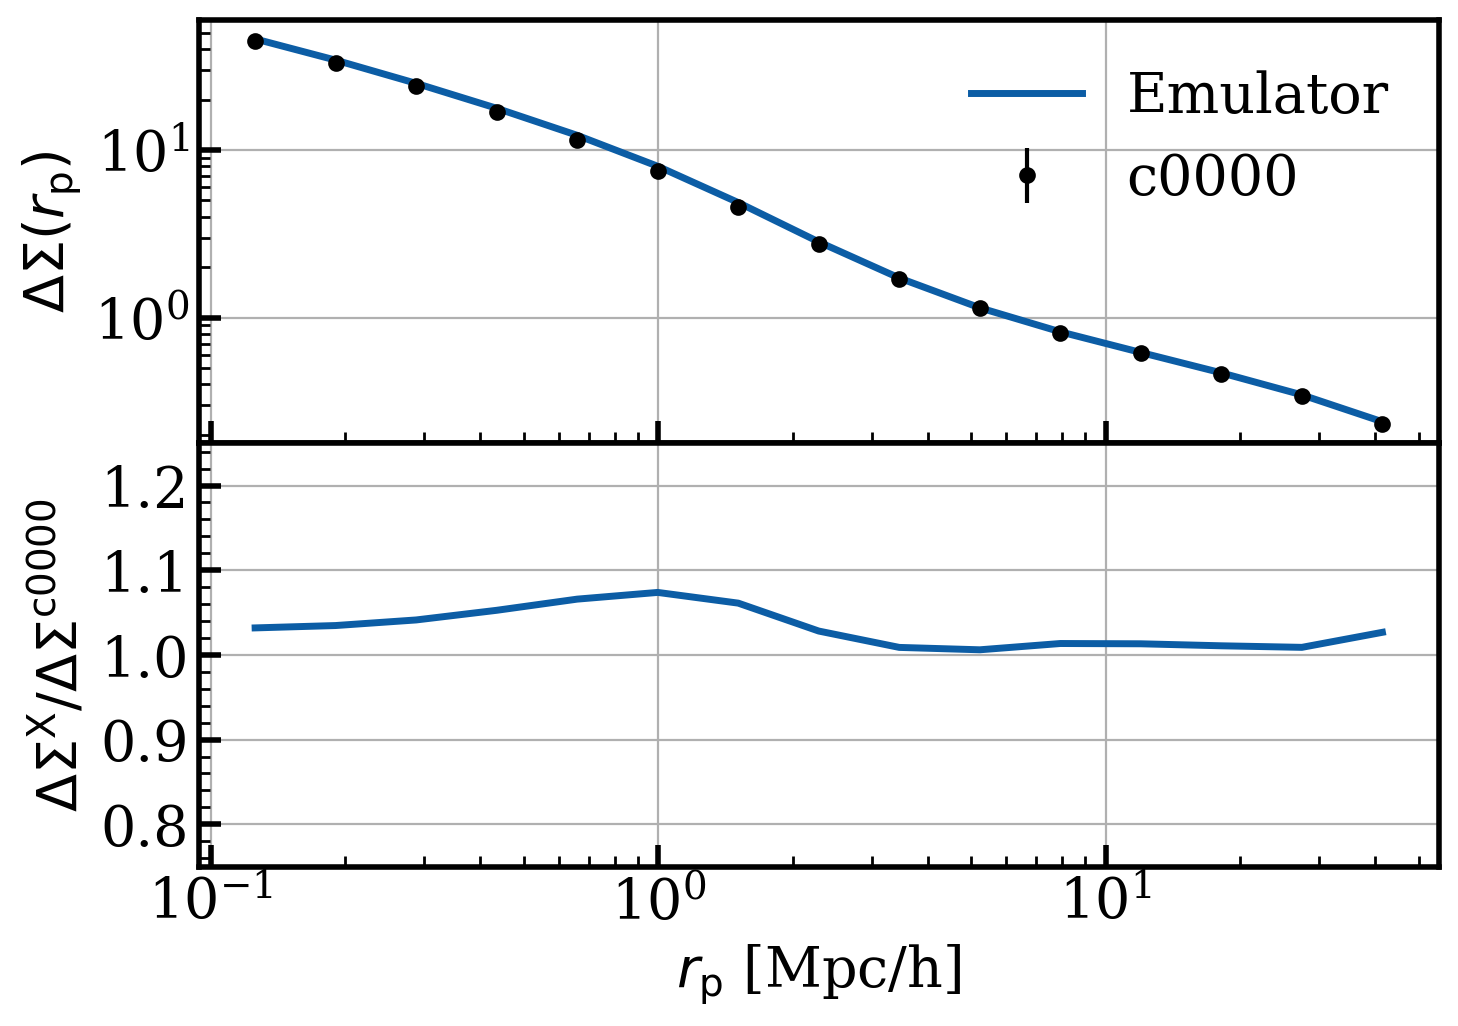

In [11]:
ds_rlz = np.zeros((16, 15))
for iseed in range(16):
    ds_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/ds-galaxy-c0000-1e12-Zheng07+fic-hod2-seed%d_M200b.npy"%(iseed))
std_ds  = np.std (ds_rlz, axis=0)
mean_ds = np.mean(ds_rlz, axis=0)

with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, ds_emu1, label="Emulator")
    # plt.plot(rmid, ds_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_ds, std_ds, lw=1.5, fmt='ko', label='c0000', markersize=5)
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$\Delta\Sigma(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.plot(rmid, ds_emu1/mean_ds, label="Emulator")
    # plt.plot(rmid, ds_emu2/mean_ds, label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    plt.ylim([0.75, 1.25])
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$\Delta\Sigma^\mathrm{X}/\Delta\Sigma^\mathrm{c0000}$")

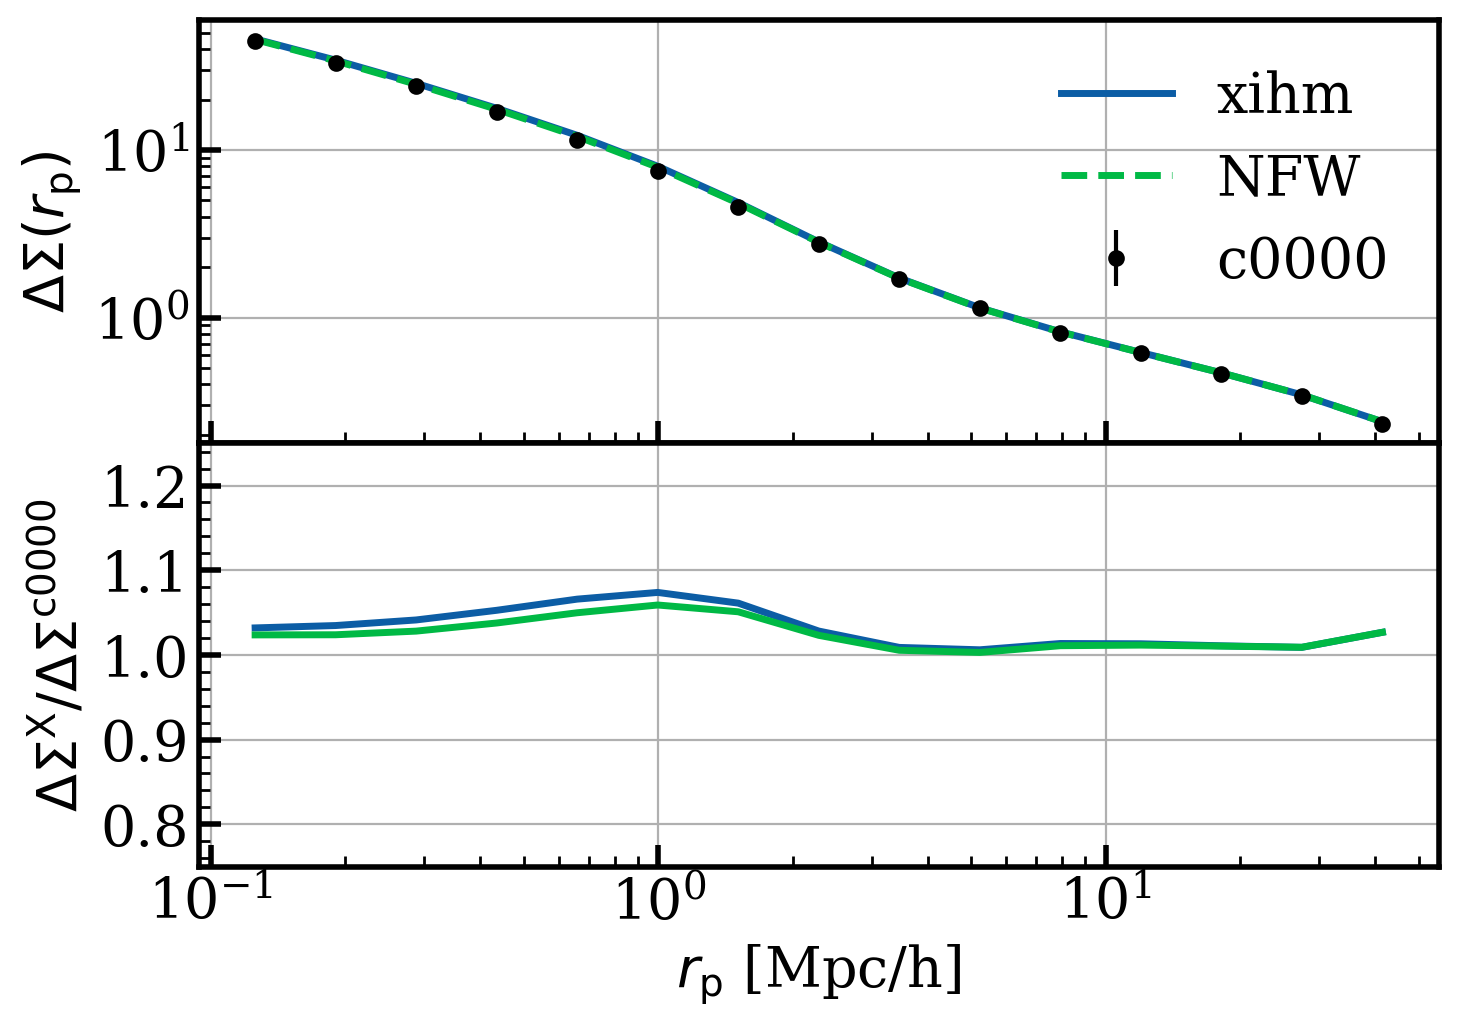

In [10]:
ds_rlz = np.zeros((16, 15))
for iseed in range(16):
    ds_rlz[iseed] = np.load("/Users/chenzhao/Desktop/mocktest/ds-galaxy-c0000-1e12-Zheng07+fic-hod2-seed%d_M200b.npy"%(iseed))
std_ds  = np.std (ds_rlz, axis=0)
mean_ds = np.mean(ds_rlz, axis=0)

with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, ds_emu1, label="xihm")
    plt.plot(rmid, ds_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_ds, std_ds, lw=1.5, fmt='ko', label='c0000', markersize=5)
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$\Delta\Sigma(r_\mathrm{p})$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.plot(rmid, ds_emu1/mean_ds, label="xihm")
    plt.plot(rmid, ds_emu2/mean_ds, label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    plt.ylim([0.75, 1.25])
    plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
    plt.ylabel(r"$\Delta\Sigma^\mathrm{X}/\Delta\Sigma^\mathrm{c0000}$")

/Users/chenzhao/Desktop/work/softwares/csstemu/examples/../CEmulator/hankl/preprocess.py:170: RuntimeWarning: invalid value encountered in scalar divide
  f_left = f[0] * (f[1] / f[0]) ** np.arange(-N_left, 0)
/Users/chenzhao/Desktop/work/softwares/csstemu/examples/../CEmulator/hankl/preprocess.py:184: RuntimeWarning: invalid value encountered in scalar divide
  f_right = f[-1] * (f[-1] / f[-2]) ** np.arange(1, N_right + 1)


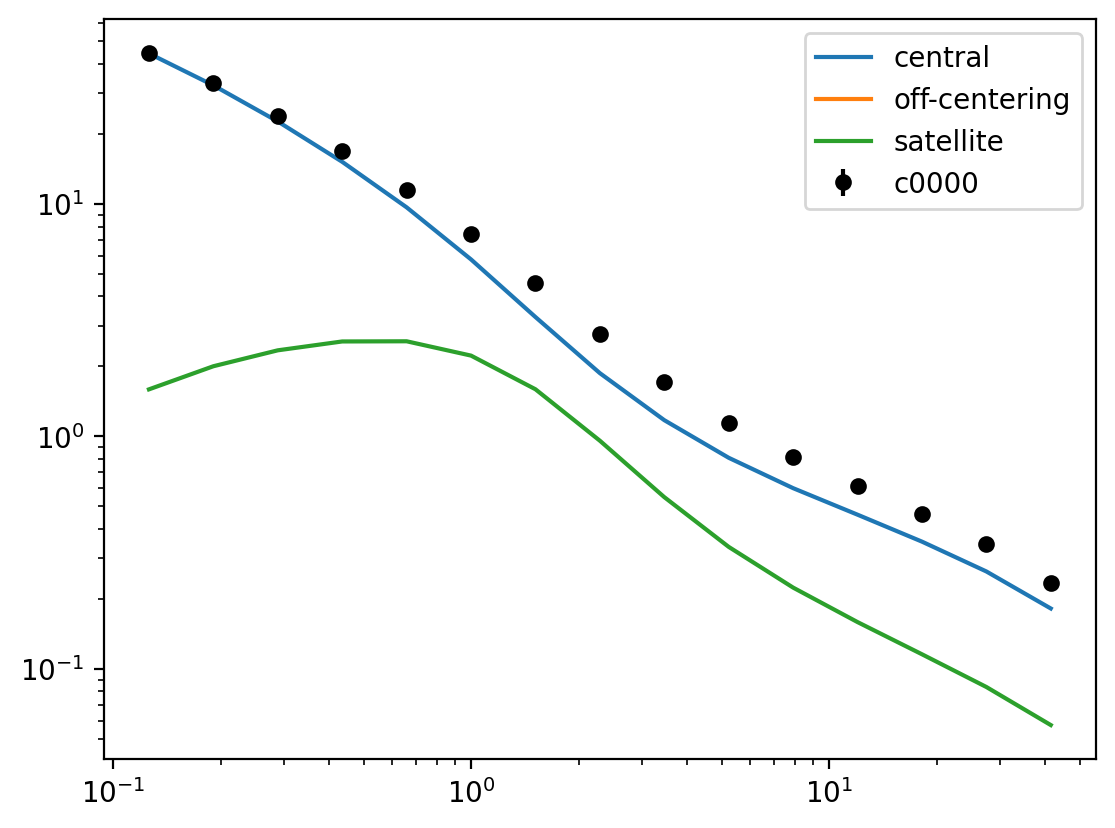

In [10]:
ds_cen, ds_off, ds_sat = emu.DeltaSigma_components(rmid, z=z)

plt.loglog(rmid, ds_cen, label="central")
plt.loglog(rmid, ds_off, label="off-centering")
plt.loglog(rmid, ds_sat, label="satellite")
plt.errorbar(rmid, mean_ds, std_ds, lw=1.5, fmt='ko', label='c0000', markersize=5)
plt.legend()

(16,)


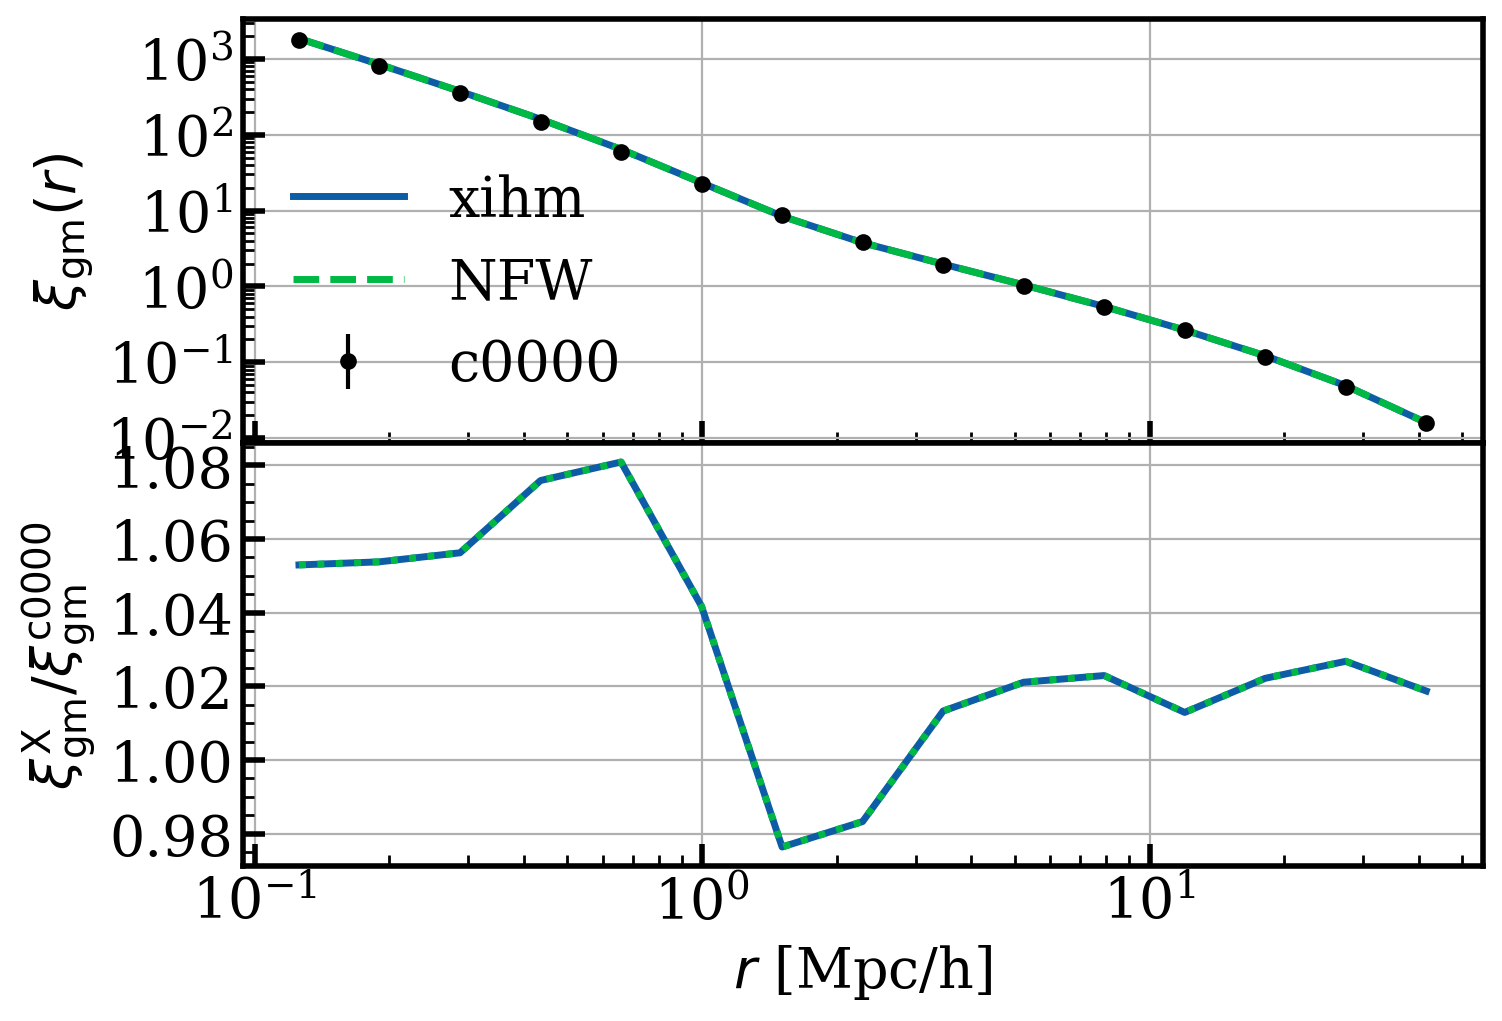

In [10]:
emu._galaxy_calc.satellite_profile.profile_type = "xihm"
xigm_emu1 = emu.Xigm(rmid, z)
emu._galaxy_calc.satellite_profile.profile_type = "nfw"
xigm_emu2 = emu.Xigm(rmid, z)

xigm_rlz = np.load("/Users/chenzhao/Desktop/mocktest/xigm-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy", allow_pickle=True)
print(xigm_rlz.shape)
std_xigm  = np.std (xigm_rlz, axis=0)
mean_xigm = np.mean(xigm_rlz, axis=0)
with plt.style.context("mypresentation"):
    gridp = plt.GridSpec(2, 1, wspace=0.0, hspace=0.0)
    plt.subplot(gridp[0])
    plt.plot(rmid, xigm_emu1, label="xihm")
    plt.plot(rmid, xigm_emu2, '--', label ="NFW")
    plt.errorbar(rmid, mean_xigm, std_xigm, lw=1.5, fmt='ko', label='c0000', markersize=5)
    plt.legend()
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r"$\xi_{\rm gm}(r)$")
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.plot(rmid, xigm_emu1/mean_xigm, label="xihm")
    plt.plot(rmid, xigm_emu2/mean_xigm, ':', label="NFW")
    plt.grid(True)
    plt.xscale('log') 
    # plt.ylim([0.975, 1.025])
    plt.xlabel(r"$r$ [Mpc/h]")
    plt.ylabel(r"$\xi_{\rm gm}^\mathrm{X}/\xi_{\rm gm}^\mathrm{c0000}$")

(16, 512)
(512,) (512,)
(512,) (512,)
(512,) (512,)


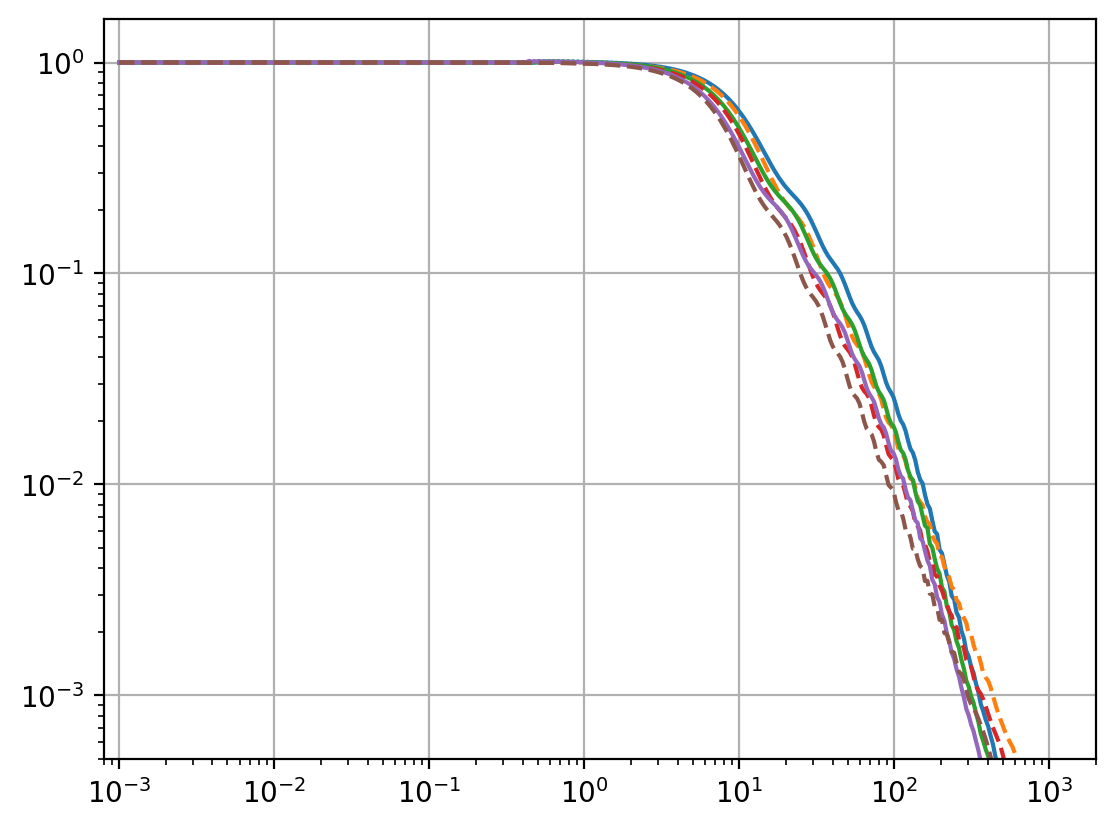

In [11]:
k_grid = emu._galaxy_calc.fftbase.k
r_grid = emu._galaxy_calc.fftbase.r
M_arr  = emu._galaxy_calc.M_grid
xihm_tt = emu._galaxy_calc._get_xi_hm_for_masses(z, r_grid, M_arr)[0] # len(M), len(z), len(r)
print(xihm_tt.shape)
R200 = emu._galaxy_calc.satellite_profile.R200(M_arr, z)
for ii in range(3):
    uk0 = emu._galaxy_calc.satellite_profile.compute_p_hm_dist_emu(k_grid, r_grid, xihm_tt[ii], R200[ii], None)
    uk1 = emu._galaxy_calc.satellite_profile.compute_p_hm_dist_nfw(k_grid, M_arr[ii], z)
    print(uk0.shape, uk1.shape)
    plt.loglog(k_grid, uk0, label="xihm")
    plt.loglog(k_grid, uk1, '--', label="NFW")
plt.xlim([8e-4, 2e3])
plt.ylim([5e-4, 1.6])
plt.grid(True)

## Separate gal_type

ncen = 5.9460e-04 h^3/Mpc^3
nsat = 1.2571e-04 h^3/Mpc^3
ngal = 7.2030e-04 h^3/Mpc^3


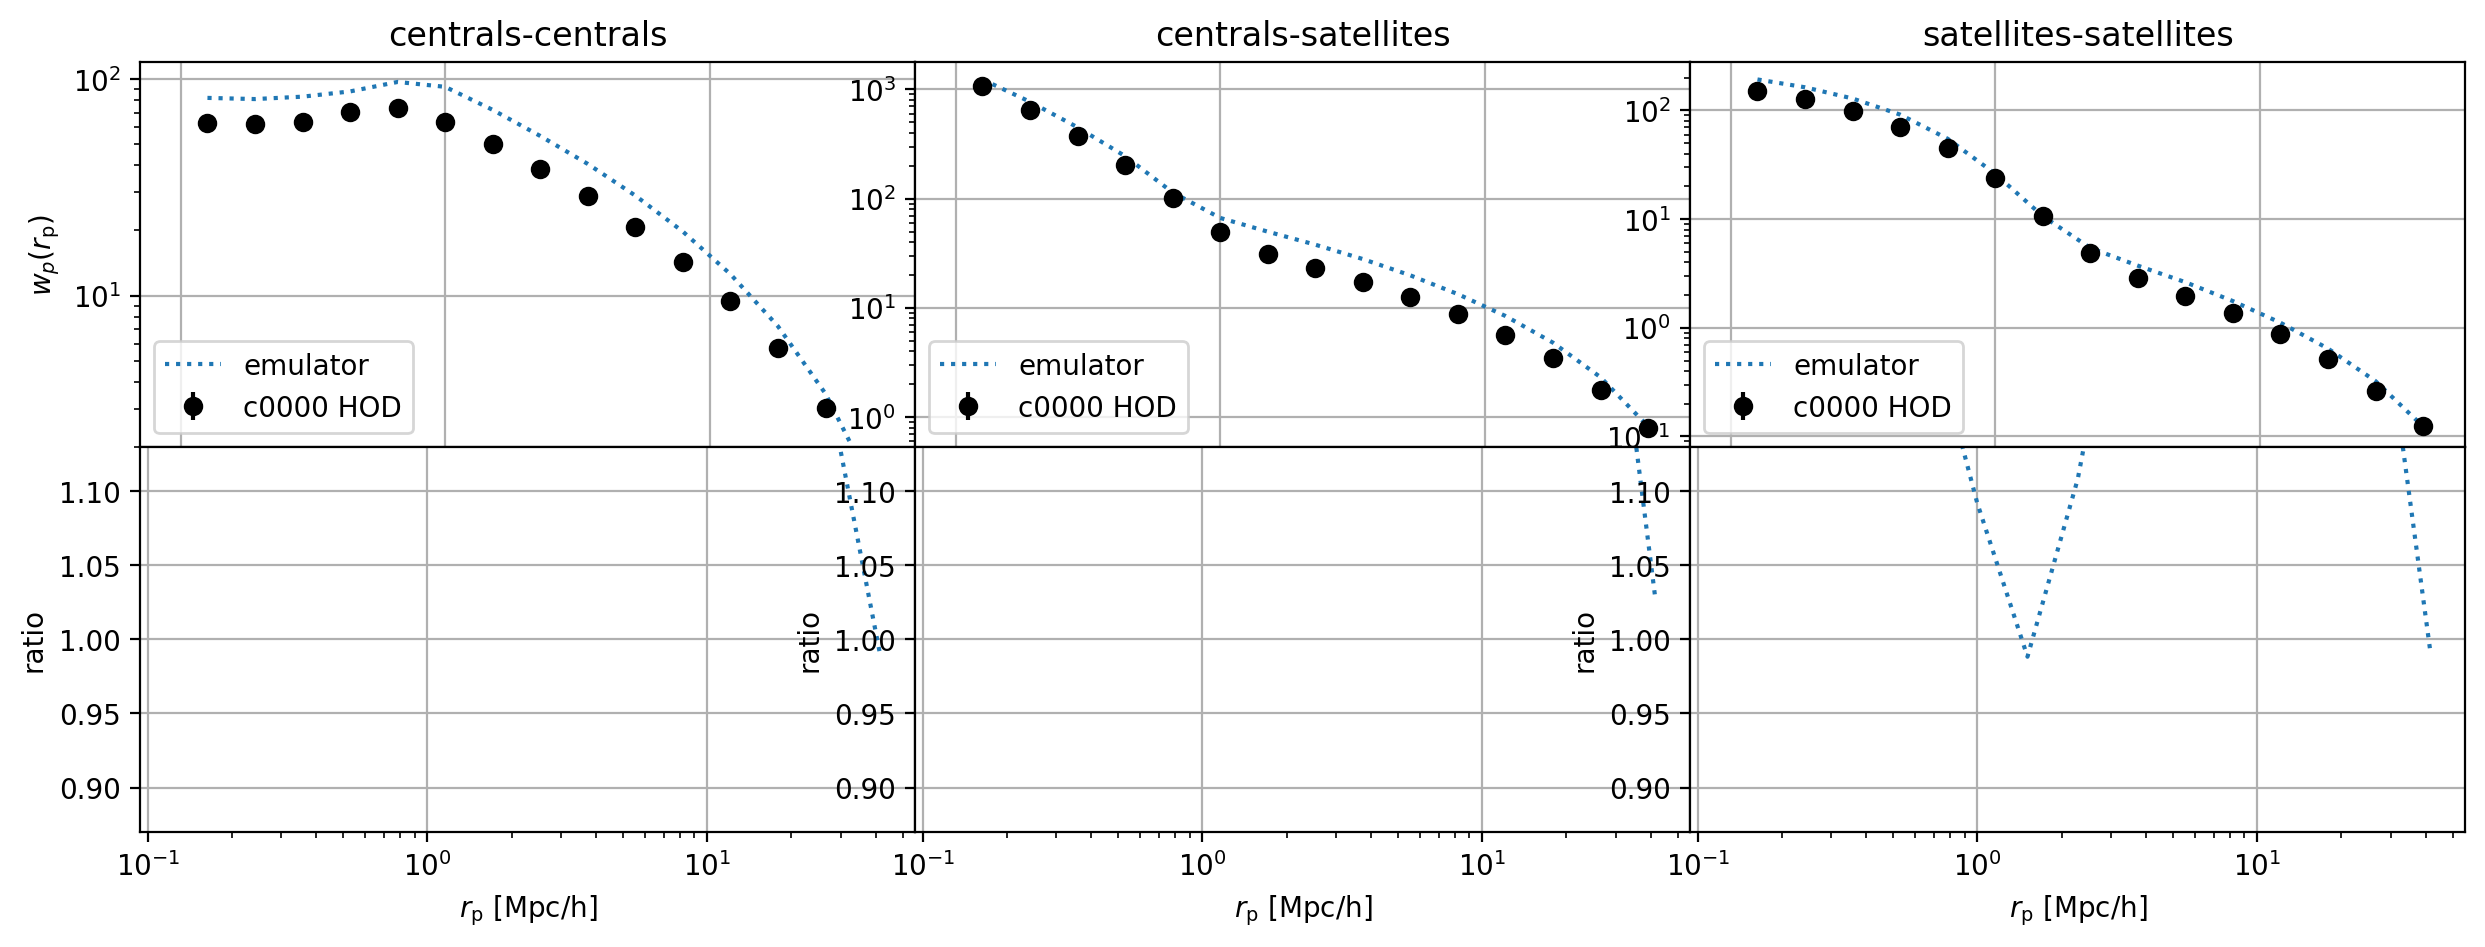

In [2]:
emu._galaxy_calc.satellite_profile.profile_type = "xihm"

wp_cc_2h = emu.wp_cc_2h(rp=rmid, z=z, pimax=100)
wp_cs_2h = emu.wp_cs_2h(rp=rmid, z=z, pimax=100)
wp_ss_2h = emu.wp_ss_2h(rp=rmid, z=z, pimax=100)
wp_cs_1h = emu.wp_cs_1h(rp=rmid, z=z, pimax=100)
wp_ss_1h = emu.wp_ss_1h(rp=rmid, z=z, pimax=100)

fname = "/Users/chenzhao/Desktop/mocktest/wp-separate-pimax100-rprbins1-c0000-z0.5000-M1.0e+12-Zheng07+fic-hod2-base-c0000-chi-Corrfunc-TabCorr.npy"
wp_cs = 2 * wp_cs_1h + 2 * wp_cs_2h
wp_ss = wp_ss_1h + wp_ss_2h
wp_sim = np.load(fname, allow_pickle=True).item()


from scipy.integrate import simpson
M_grid = np.logspace(11, 16, 100)
Ncen = emu._hod_model.Ncen(M_grid, **emu._hod_params)
Nsat = emu._hod_model.Nsat(M_grid, **emu._hod_params)
dndlnM = np.atleast_1d(np.squeeze(
                emu._galaxy_calc.hmf.get_dndlnM(z=redshift, M=M_grid)))
ncen = simpson(dndlnM * (Ncen), x=np.log(M_grid))
nsat = simpson(dndlnM * (Nsat), x=np.log(M_grid))
ngal = simpson(dndlnM * (Ncen+Nsat), x=np.log(M_grid))
print(f"ncen = {ncen:.4e} h^3/Mpc^3")
print(f"nsat = {nsat:.4e} h^3/Mpc^3")
print(f"ngal = {ngal:.4e} h^3/Mpc^3")

wp_cc_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpcc-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_cc_hod = wp_cc_hod * ncen**2 / ngal**2
wp_cc_hod_mean = np.mean(wp_cc_hod, axis=0)
wp_cc_hod_std  = np.std (wp_cc_hod, axis=0)
wp_cs_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpcs-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_cs_hod = wp_cs_hod * (nsat / ngal) * (ncen / ngal) * 2
wp_cs_hod_mean = np.mean(wp_cs_hod, axis=0)
wp_cs_hod_std  = np.std (wp_cs_hod, axis=0)
wp_ss_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpss-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_ss_hod = wp_ss_hod * nsat**2 / ngal**2
wp_ss_hod_mean = np.mean(wp_ss_hod, axis=0)
wp_ss_hod_std  = np.std (wp_ss_hod, axis=0)



gridp = plt.GridSpec(2, 3, wspace=0.0, hspace=0.0)
plt.figure(figsize=(15, 5))
plt.subplot(gridp[0,0])
# plt.plot(rmid, wp_sim["centrals-centrals"])
plt.plot(rmid, wp_cc_2h, ":", label="emulator")
plt.errorbar(rmid, wp_cc_hod_mean, yerr=wp_cc_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("centrals-centrals")
plt.ylim([2,120])
plt.xlim([7e-2, 60])
plt.grid(True)
plt.ylabel(r"$w_p(r_\mathrm{p})$")
plt.legend(loc="lower left")
plt.subplot(gridp[1,0])
plt.plot(rmid, wp_cc_2h/wp_cc_hod_mean, ":")
plt.ylabel("ratio")
plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
plt.ylim(0.87,1.13)
plt.xscale('log')
plt.grid(True)

plt.subplot(gridp[0,1])
# plt.plot(rmid, wp_sim["centrals-satellites"])
plt.plot(rmid, wp_cs, ":", label="emulator")
plt.errorbar(rmid, wp_cs_hod_mean, yerr=wp_cs_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("centrals-satellites")
plt.xlim([7e-2, 60])
plt.grid(True)
plt.legend(loc="lower left")
plt.subplot(gridp[1,1])
plt.plot(rmid, wp_cs/wp_cs_hod_mean, ":")
plt.ylabel("ratio")
plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
plt.ylim(0.87,1.13)
plt.xscale('log')
plt.grid(True)

plt.subplot(gridp[0,2])
# plt.plot(rmid, wp_sim["satellites-satellites"])
plt.plot(rmid, wp_ss, ":", label="emulator")
plt.errorbar(rmid, wp_ss_hod_mean, yerr=wp_ss_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("satellites-satellites")
plt.xlim([7e-2, 60])
plt.grid(True)
plt.legend(loc="lower left")
plt.subplot(gridp[1,2])
plt.plot(rmid, wp_ss/wp_ss_hod_mean, ":")
plt.ylabel("ratio")
plt.xlabel(r"$r_\mathrm{p}$ [Mpc/h]")
plt.ylim(0.87,1.13)
plt.xscale('log')
plt.grid(True)

0.5
(16,)
0.0005821746723167541 0.0001256049732419906 0.0007077796455587451
(16, 16, 2048)
(384,)
(512,)


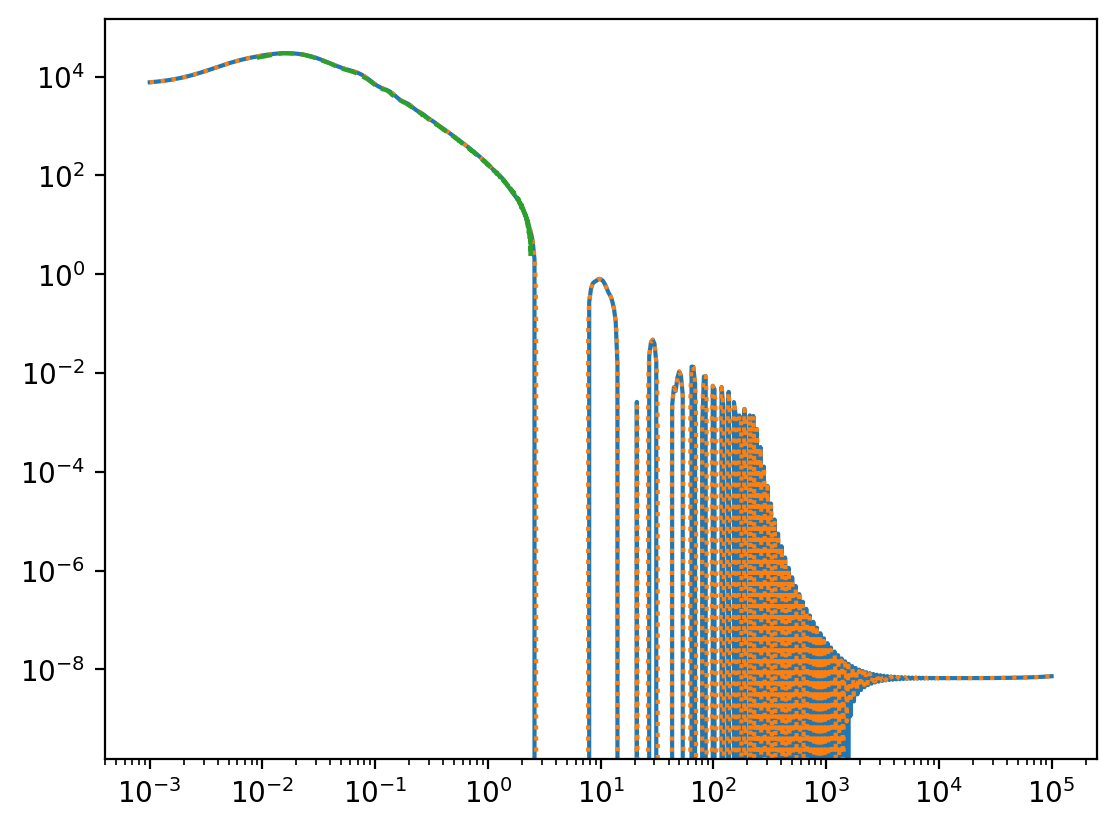

In [4]:
from scipy.integrate import simpson
print(z)
M_arr = emu._galaxy_calc.M_grid
dndlnM = emu.get_dndlnM(z, M_arr)[0]
print(dndlnM.shape)
Ncen, Nsat, Ngal = emu._galaxy_calc._get_cached_hod_weights(emu._hod_model, **emu._hod_params)
ncen = simpson(dndlnM * Ncen, x=np.log(M_arr))
nsat = simpson(dndlnM * Nsat, x=np.log(M_arr))
ngal = simpson(dndlnM * Ngal, x=np.log(M_arr))
print(ncen, nsat, ngal)
k = emu._galaxy_calc.fftbase.k
k2 = np.logspace(-3, 5, 2048)
phh = emu._galaxy_calc._get_pkhh_for_masses(z, k2, M_arr, M_arr)
print(phh.shape)
pcc2 = emu._galaxy_calc._double_mass_integral(dndlnM, np.log(M_arr), Ncen[None,:], Ncen[None,:], phh)/ngal/ngal

Pcc_sim = np.load("/Users/chenzhao/Desktop/mocktest/Pcc-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy", allow_pickle=True)
print(Pcc_sim[0][1].shape)
pcc_mean = np.zeros(Pcc_sim[0][1].shape)
for ii in range(16):
    pcc_mean += Pcc_sim[ii][1]
pcc_mean = pcc_mean / 16
r = emu._galaxy_calc.fftbase.r
Pcc = emu._galaxy_calc.compute_Pcc_2h(k=k, z=z, hod_model=emu._hod_model, **emu._hod_params)
print(Pcc.shape)
plt.loglog(k, Pcc, label="emulator")
plt.loglog(k2, pcc2, ':')
plt.loglog(Pcc_sim[0][0][1:], (ncen/ngal)**2 * pcc_mean[1:], '--', label="c0000 HOD")

In [53]:
emu._galaxy_calc._phh_matrix_cache[0]

array([0.  , 0.1 , 0.25, 0.5 , 0.8 , 1.  , 1.25, 1.5 , 1.75, 2.  , 2.5 ,
       3.  ])

0.5
0.0005821746723167541 0.0001256049732419906 0.0007077796455587451
(16, 16, 512) (12, 16, 16, 512)
(16, 16, 512)
(15,) (16,)


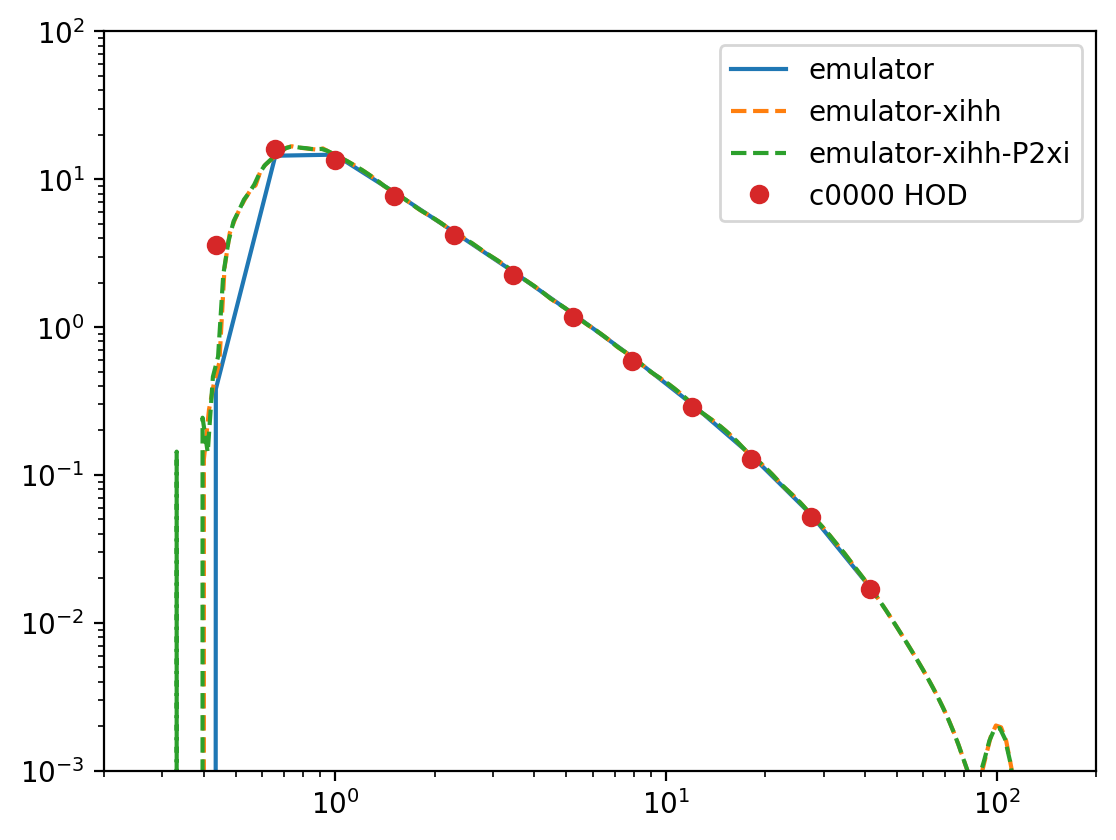

In [2]:
from scipy.integrate import simpson
from CEmulator.hankl import pk2xi, xi2pk
print(z)
# M_arr = emu._galaxy_calc.M_grid
M_arr = np.logspace(12.5, 15.5, 16)
dndlnM = emu.get_dndlnM(z, M_arr)[0]
# Ncen, Nsat, Ngal = emu._galaxy_calc._get_cached_hod_weights(emu._hod_model, **emu._hod_params)
Ncen = emu._hod_model.Ncen(M_arr, **emu._hod_params)
Nsat = emu._hod_model.Nsat(M_arr, **emu._hod_params)
Ngal = Ncen + Nsat
ncen = simpson(dndlnM * Ncen, x=np.log(M_arr))
nsat = simpson(dndlnM * Nsat, x=np.log(M_arr))
ngal = simpson(dndlnM * Ngal, x=np.log(M_arr))
print(ncen, nsat, ngal)

r = emu._galaxy_calc.fftbase.r
xihh  = emu._galaxy_calc._get_xihh_mass_blend_grid(z, r=r, M1=M_arr, M2=M_arr)
print(xihh.shape, emu._galaxy_calc._xi_hh_full.shape)
W1 = Ncen[None,:] / ngal
xicc2 = emu._galaxy_calc._double_mass_integral(dndlnM, np.log(M_arr), W1, W1, xihh)

# k3 = emu._galaxy_calc.fftbase.k
k3 = np.logspace(-5, 3, 512)
xihh3 = np.zeros((len(M_arr), len(M_arr), len(k3)))
phhtt = emu._galaxy_calc._get_pkhh_for_masses(z, k3, M_arr, M_arr)
# print(emu._galaxy_calc._phh_matrix_cache[0], emu._galaxy_calc._phh_matrix_cache[4].shape)
# phhtt = emu._galaxy_calc._phh_matrix_cache[4][3]
print(phhtt.shape)
for ii in range(len(M_arr)):
    for jj in range(len(M_arr)):
        r3, xitt = pk2xi(k3, phhtt[ii, jj], ext=0, lowring=False)
        xihh3[ii, jj] = xitt.real
xicc3 = emu._galaxy_calc._double_mass_integral(dndlnM, np.log(M_arr), W1, W1, xihh3)

xicc_emu = emu._galaxy_calc.compute_Xigg_cc_2h(rmid, z, emu._hod_model, **emu._hod_params)
xicc_sim = np.load("/Users/chenzhao/Desktop/mocktest/xicc-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy", allow_pickle=True)
xicc_sim = xicc_sim * (ncen/ngal)**2
print(xicc_emu.shape, xicc_sim.shape)
plt.loglog(rmid, xicc_emu, label="emulator")
plt.loglog(r, xicc2, '--', label="emulator-xihh")
plt.loglog(r3, xicc3, '--', label="emulator-xihh-P2xi")
plt.loglog(rmid, np.mean(xicc_sim, axis=0), 'o', label="c0000 HOD")
plt.xlim(2e-1, 200)
plt.ylim([1e-3, 1e2])
plt.legend()

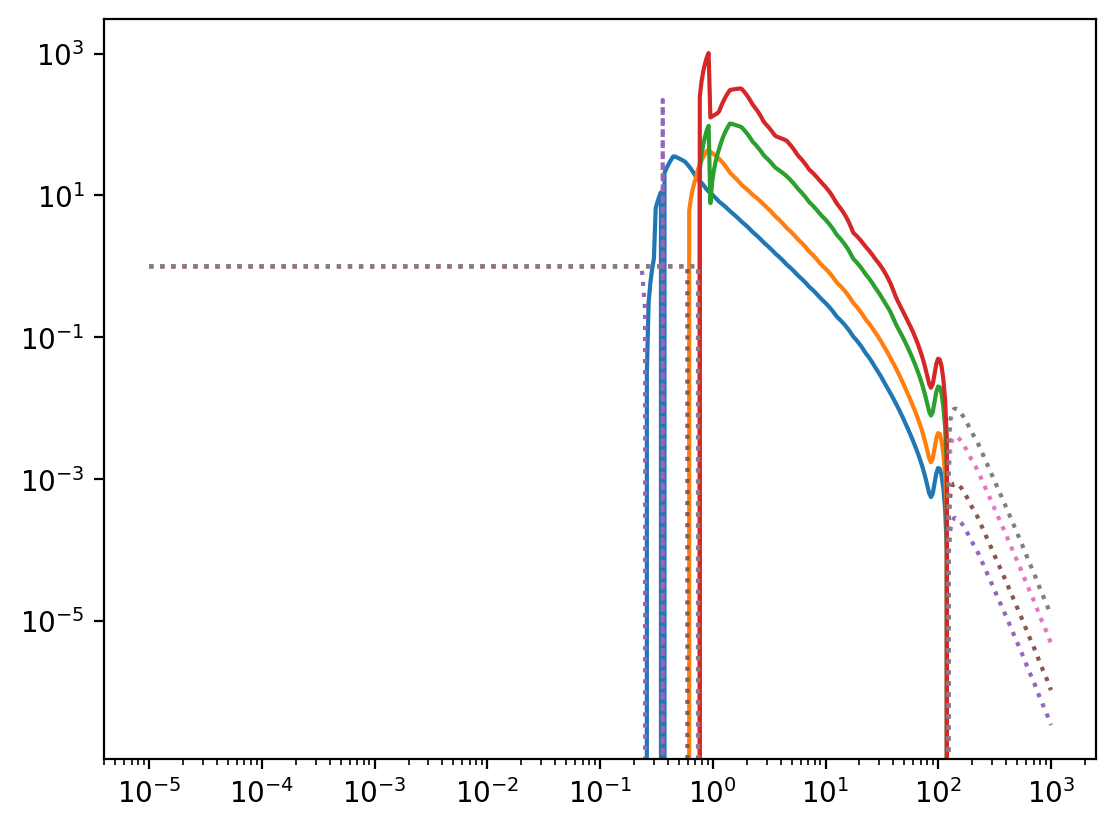

In [5]:
plt.loglog(r, xihh[0,0])
plt.loglog(r, xihh[5,5])
plt.loglog(r, xihh[10,10])
plt.loglog(r, xihh[15,15])
plt.loglog(r, -xihh[0,0], ':')
plt.loglog(r, -xihh[5,5], ':')
plt.loglog(r, -xihh[10,10], ':')
plt.loglog(r, -xihh[15,15], ':')

In [8]:
Ncen, Nsat, Ngal = emu._galaxy_calc._get_cached_hod_weights(emu._hod_model, **emu._hod_params)
# print(Nsat)
# print(Ncen)
print(Nsat*Nsat)
print(Nsat*Nsat/Ncen)

[0.00000000e+00 9.09268477e-06 8.09849457e-04 9.25072966e-03
 4.14413873e-02 1.28129504e-01 3.53662850e-01 9.35519117e-01
 2.41818296e+00 6.16421700e+00 1.55791375e+01 3.91647367e+01
 9.81298293e+01 2.45357868e+02 6.12673202e+02 1.52861796e+03]
[0.00000000e+00 4.70230630e-05 1.53413199e-03 1.09779180e-02
 4.25532723e-02 1.28387622e-01 3.53687224e-01 9.35520080e-01
 2.41818297e+00 6.16421700e+00 1.55791375e+01 3.91647367e+01
 9.81298293e+01 2.45357868e+02 6.12673202e+02 1.52861796e+03]


ncen = 5.9460e-04 h^3/Mpc^3
nsat = 1.2571e-04 h^3/Mpc^3
ngal = 7.2030e-04 h^3/Mpc^3


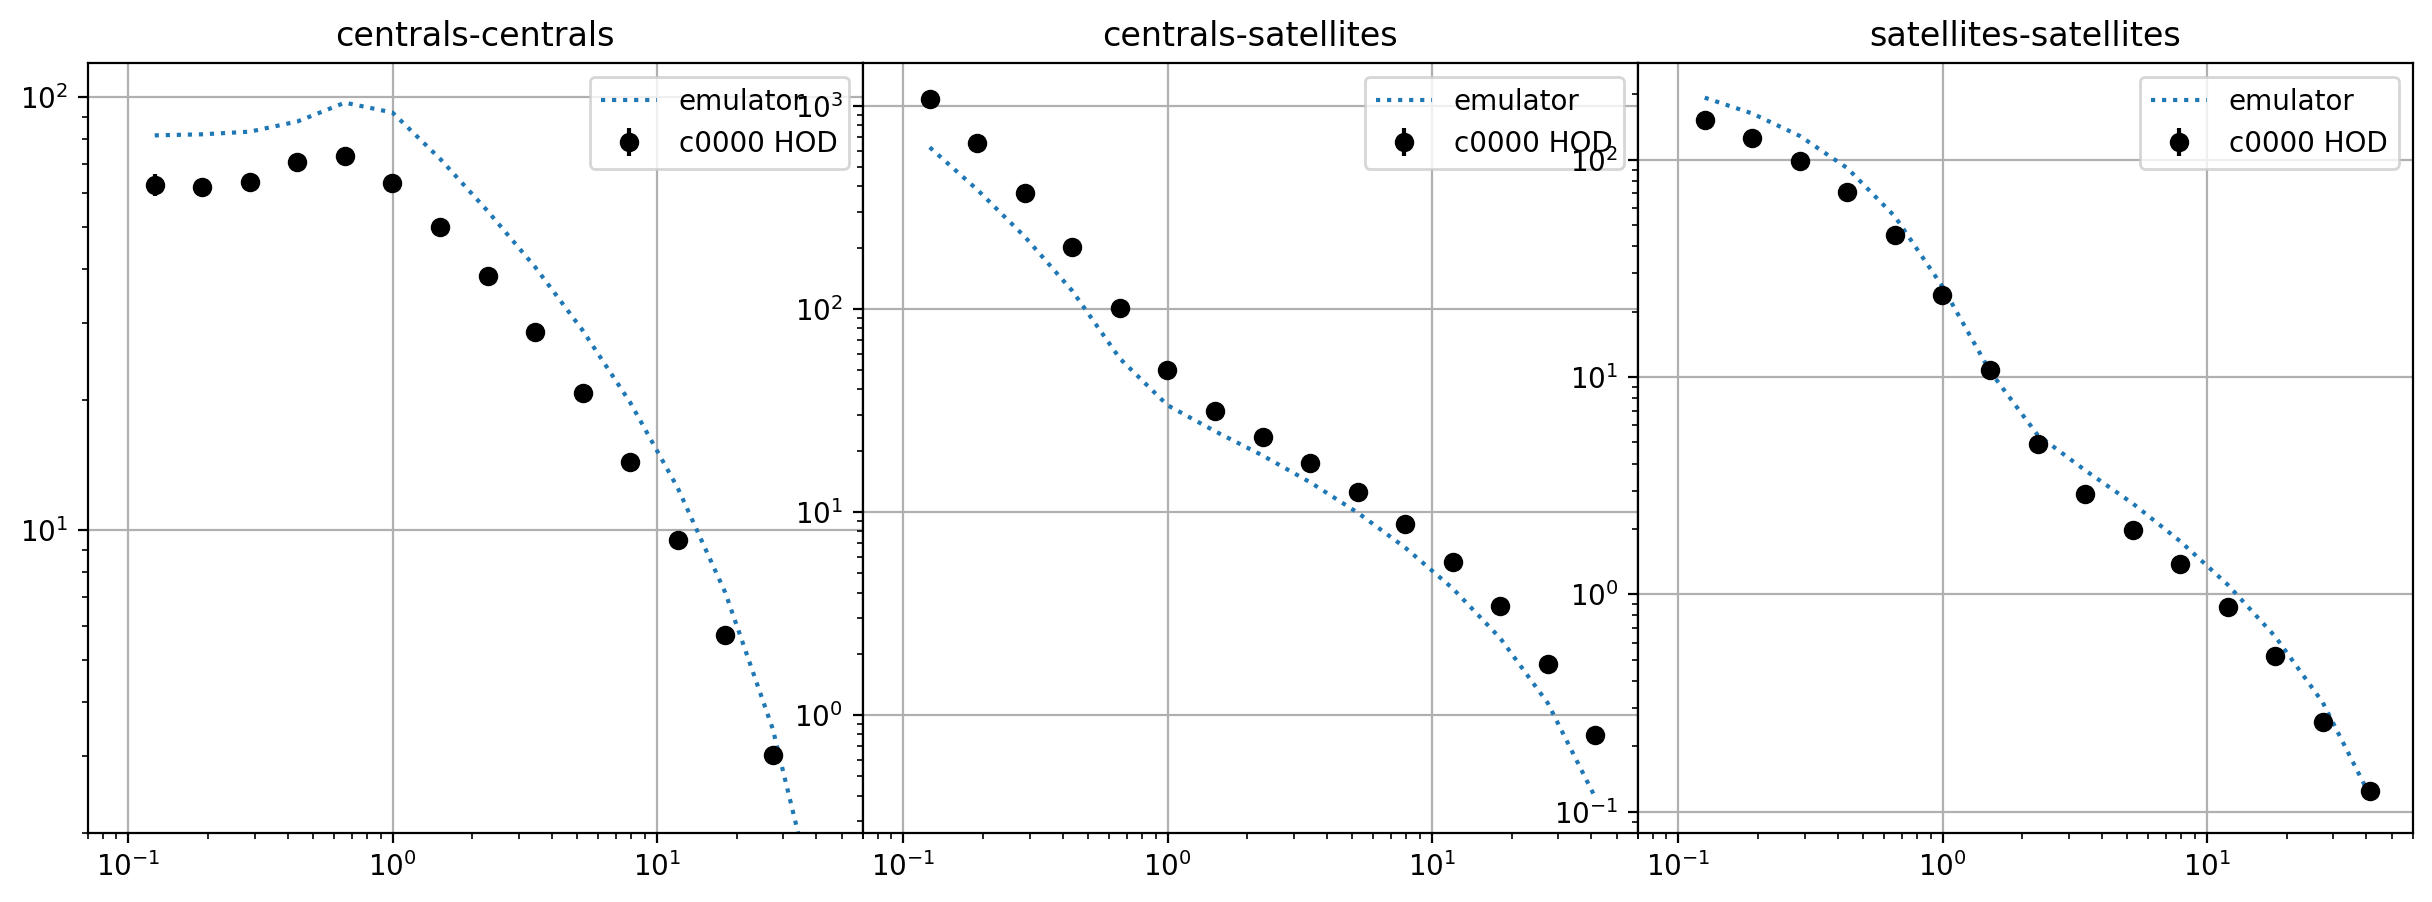

In [9]:
##### the impact of pimax

emu._galaxy_calc.satellite_profile.profile_type = "xihm"

wp_cc_2h = emu.wp_cc_2h(rp=rmid, z=z, pimax=None)
wp_cs_2h = emu.wp_cs_2h(rp=rmid, z=z, pimax=None)
wp_ss_2h = emu.wp_ss_2h(rp=rmid, z=z, pimax=None)
wp_cs_1h = emu.wp_cs_1h(rp=rmid, z=z, pimax=None)
wp_ss_1h = emu.wp_ss_1h(rp=rmid, z=z, pimax=None)

fname = "/Users/chenzhao/Desktop/mocktest/wp-separate-pimax100-rprbins1-c0000-z0.5000-M1.0e+12-Zheng07+fic-hod2-base-c0000-chi-Corrfunc-TabCorr.npy"
wp_sim = np.load(fname, allow_pickle=True).item()


from scipy.integrate import simpson
M_grid = np.logspace(11, 16, 100)
Ncen = emu._hod_model.Ncen(M_grid, **emu._hod_params)
Nsat = emu._hod_model.Nsat(M_grid, **emu._hod_params)
dndlnM = np.atleast_1d(np.squeeze(
                emu._galaxy_calc.hmf.get_dndlnM(z=redshift, M=M_grid)))
ncen = simpson(dndlnM * (Ncen), x=np.log(M_grid))
nsat = simpson(dndlnM * (Nsat), x=np.log(M_grid))
ngal = simpson(dndlnM * (Ncen+Nsat), x=np.log(M_grid))
print(f"ncen = {ncen:.4e} h^3/Mpc^3")
print(f"nsat = {nsat:.4e} h^3/Mpc^3")
print(f"ngal = {ngal:.4e} h^3/Mpc^3")

wp_cc_2h = wp_cc_2h #* ncen**2 / ngal**2
wp_cs = (wp_cs_1h + wp_cs_2h) # * 2 *  (nsat / ngal) * (ncen / ngal)
wp_ss = (wp_ss_1h + wp_ss_2h) # * nsat**2 / ngal**2


wp_cc_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpcc-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_cc_hod = wp_cc_hod * ncen**2 / ngal**2
wp_cc_hod_mean = np.mean(wp_cc_hod, axis=0)
wp_cc_hod_std  = np.std (wp_cc_hod, axis=0)
wp_cs_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpcs-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_cs_hod = wp_cs_hod * (nsat / ngal) * (ncen / ngal) * 2
wp_cs_hod_mean = np.mean(wp_cs_hod, axis=0)
wp_cs_hod_std  = np.std (wp_cs_hod, axis=0)
wp_ss_hod = np.load("/Users/chenzhao/Desktop/mocktest/wpss-galaxy-c0000-1e12-Zheng07+fic-hod2-seed0-15_M200b.npy")
wp_ss_hod = wp_ss_hod * nsat**2 / ngal**2
wp_ss_hod_mean = np.mean(wp_ss_hod, axis=0)
wp_ss_hod_std  = np.std (wp_ss_hod, axis=0)

gridp = plt.GridSpec(1, 3, wspace=0.0, hspace=0.0)
plt.figure(figsize=(15, 5))
plt.subplot(gridp[0])
# plt.plot(rmid, wp_sim["centrals-centrals"])
plt.plot(rmid, wp_cc_2h, ":", label="emulator")
plt.errorbar(rmid, wp_cc_hod_mean, yerr=wp_cc_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("centrals-centrals")
plt.ylim([2,120])
plt.xlim([7e-2, 60])
plt.grid(True)
plt.legend()

plt.subplot(gridp[1])
# plt.plot(rmid, wp_sim["centrals-satellites"])
plt.plot(rmid, wp_cs, ":", label="emulator")
plt.errorbar(rmid, wp_cs_hod_mean, yerr=wp_cs_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("centrals-satellites")
plt.xlim([7e-2, 60])
plt.grid(True)
plt.legend()

plt.subplot(gridp[2])
# plt.plot(rmid, wp_sim["satellites-satellites"])
plt.plot(rmid, wp_ss, ":", label="emulator")
plt.errorbar(rmid, wp_ss_hod_mean, yerr=wp_ss_hod_std, fmt='o', color='k', label='c0000 HOD')
plt.xscale('log')
plt.yscale('log')
plt.title("satellites-satellites")
plt.xlim([7e-2, 60])
plt.grid(True)
plt.legend()

In [12]:
from scipy.integrate import simpson
Ncen = emu._hod_model.Ncen(emu._galaxy_calc.M_grid, **emu._hod_params)
Nsat = emu._hod_model.Nsat(emu._galaxy_calc.M_grid, **emu._hod_params)
dndlnM = np.atleast_1d(np.squeeze(
                emu._galaxy_calc.hmf.get_dndlnM(z=redshift, M=emu._galaxy_calc.M_grid)))
ngal = simpson(dndlnM * (Ncen+Nsat), x=emu._galaxy_calc.lnM_grid)
print(ngal)

0.0007199094025403505


In [13]:
from scipy.integrate import simpson
M_grid = np.logspace(11, 16, 100)
Ncen = emu._hod_model.Ncen(M_grid, **emu._hod_params)
Nsat = emu._hod_model.Nsat(M_grid, **emu._hod_params)
dndlnM = np.atleast_1d(np.squeeze(
                emu._galaxy_calc.hmf.get_dndlnM(z=redshift, M=M_grid)))
print(simpson(dndlnM * (Ncen), x=np.log(M_grid)))
print(simpson(dndlnM * (Nsat), x=np.log(M_grid)))
print(simpson(dndlnM * (Ncen+Nsat), x=np.log(M_grid)))


0.0005945950746147254
0.0001257097941487218
0.0007203048687634472


## halo statistics 

In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator
import numpy as np

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.048975
ns     = 0.9665
mnu    = 0.06
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.50

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=True)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [10]:
m_edges = np.logspace(10, 16, 60+1)
dlgM    = np.log10(m_edges[1]) - np.log10(m_edges[0])
dlnM    = np.log(m_edges[1]) - np.log(m_edges[0])
mcen    = 10**((np.log10(m_edges[1:]) + np.log10(m_edges[:-1]))/2)
zlists  = np.array([redshift])
%time dndlnM_200m  = emu.get_dndlnM(z=zlists, M=mcen, massdef='RockstarM200m')
dndlnM_simu = np.loadtxt("/Users/chenzhao/Desktop/mocktest/hmf_group_008_rockstar_Nbin60.txt")[:,4] * dlgM / dlnM

CPU times: user 669 ms, sys: 8.55 ms, total: 677 ms
Wall time: 646 ms


/var/folders/01/fk0gr9r91yq1bjz_5vw1g0y40000gn/T/ipykernel_58436/1633395594.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(mcen, dndlnM_200m[0]/dndlnM_simu)
/var/folders/01/fk0gr9r91yq1bjz_5vw1g0y40000gn/T/ipykernel_58436/1633395594.py:6: RuntimeWarning: divide by zero encountered in divide
  err = 1/np.sqrt(dndlnM_simu*dlnM*1e9)


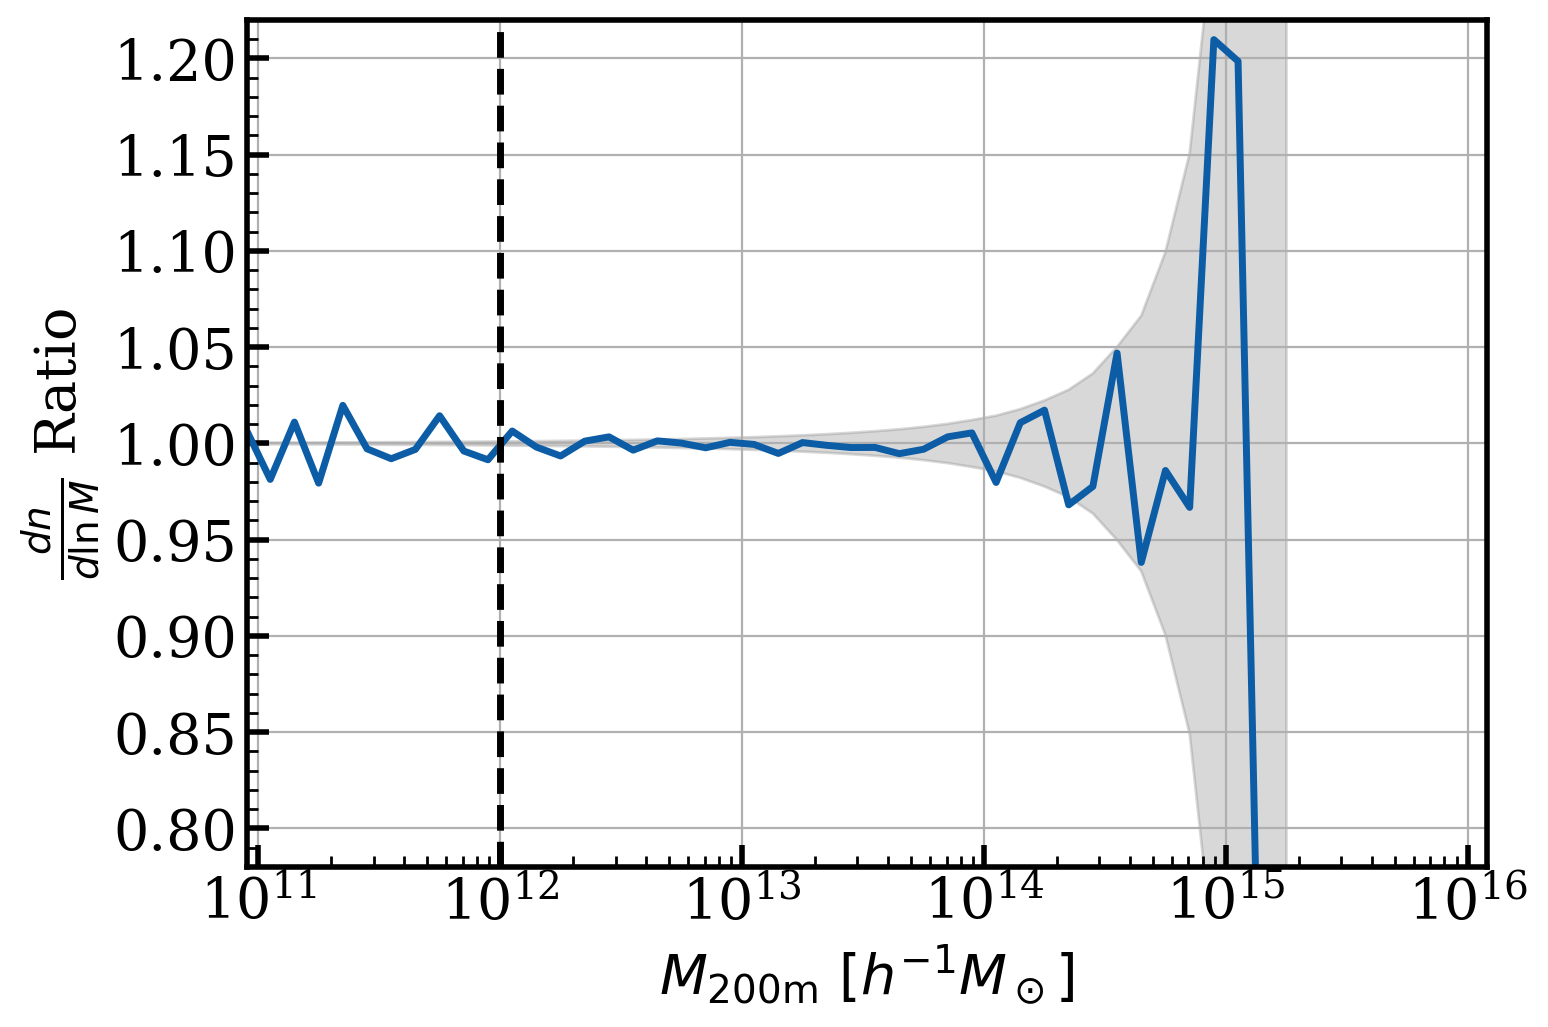

In [11]:
with plt.style.context('mypresentation'):
    plt.plot(mcen, dndlnM_200m[0]/dndlnM_simu)
    plt.xscale('log')
    plt.xlim([9e10, 1.2e16])
    plt.axvline(1e12, color='k', ls='--', label=r'$10^{12} M_\odot/h$')
    err = 1/np.sqrt(dndlnM_simu*dlnM*1e9)
    plt.fill_between(mcen, 1-err, 1+err, color='gray', alpha=0.3, label=r'$\pm 1/\sqrt{N}$')
    plt.ylim(0.78, 1.22)
    plt.xlabel(r"$M_{\rm %s}\ [h^{-1}M_\odot]$"%("200m"))
    plt.ylabel(r"$\frac{dn}{d\ln M}$ Ratio")

In [12]:
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 500, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2

xihh_sim = np.load("/Users/chenzhao/Desktop/mocktest/xihh_simu_n129_HybridNBin127_rockstar.npy")[0,8]
print(xihh_sim.shape)

dencutlist = np.logspace(-8.5, -2.5, 13)
nden  = len(dencutlist)
nauto = (nden+1)*nden // 2
ind   = 0
lgdencut1 = np.zeros((nauto))
lgdencut2 = np.zeros((nauto))
for id1 in range(nden):
    for id2 in range(nden):
        if id1 <= id2:
            lgdencut1[ind] = np.log10(dencutlist[id1])
            lgdencut2[ind] = np.log10(dencutlist[id2])
            ind += 1
idenst = 7
ind1 = lgdencut1 >= np.log10(dencutlist[idenst])
ind2 = lgdencut2 >= np.log10(dencutlist[idenst]) 
ind_den = np.arange(nauto)[ind1 * ind2]

lgdens = np.linspace(-5.0, -2.5, 6) 
idenlist = []
i0 = 0
for ii in ind_den:
    if lgdencut1[ii] == lgdens[i0] and lgdencut2[ii] == lgdens[i0]:
        idenlist.append(ii)
        i0 += 1
print(idenlist)
print(lgdencut1[idenlist])
print(lgdencut2[idenlist])

lgdens = np.linspace(-5.0, -2.5, 6) 
xihh_emu = np.zeros((len(zlists), len(lgdens), len(rmid)))
for ii in range(len(lgdens)):
    xihh_emu[:,ii] = emu.Xihh.get_xihh_lgnbar_threshold(r=rmid, z=redshift, lgden1=lgdens[ii], lgden2=lgdens[ii])
print(xihh_emu.shape)

(91, 127)
[70, 76, 81, 85, 88, 90]
[-5.  -4.5 -4.  -3.5 -3.  -2.5]
[-5.  -4.5 -4.  -3.5 -3.  -2.5]
Loading Xihh emulator...
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir_bound emulator...
Using 129 training samples.
Loading the bhmNumBin_RockstarM200m emulator...
Using 129 training samples.
Loading the hNumBin_RockstarM200m emulator...
Using 129 training samples.
(1, 6, 127)


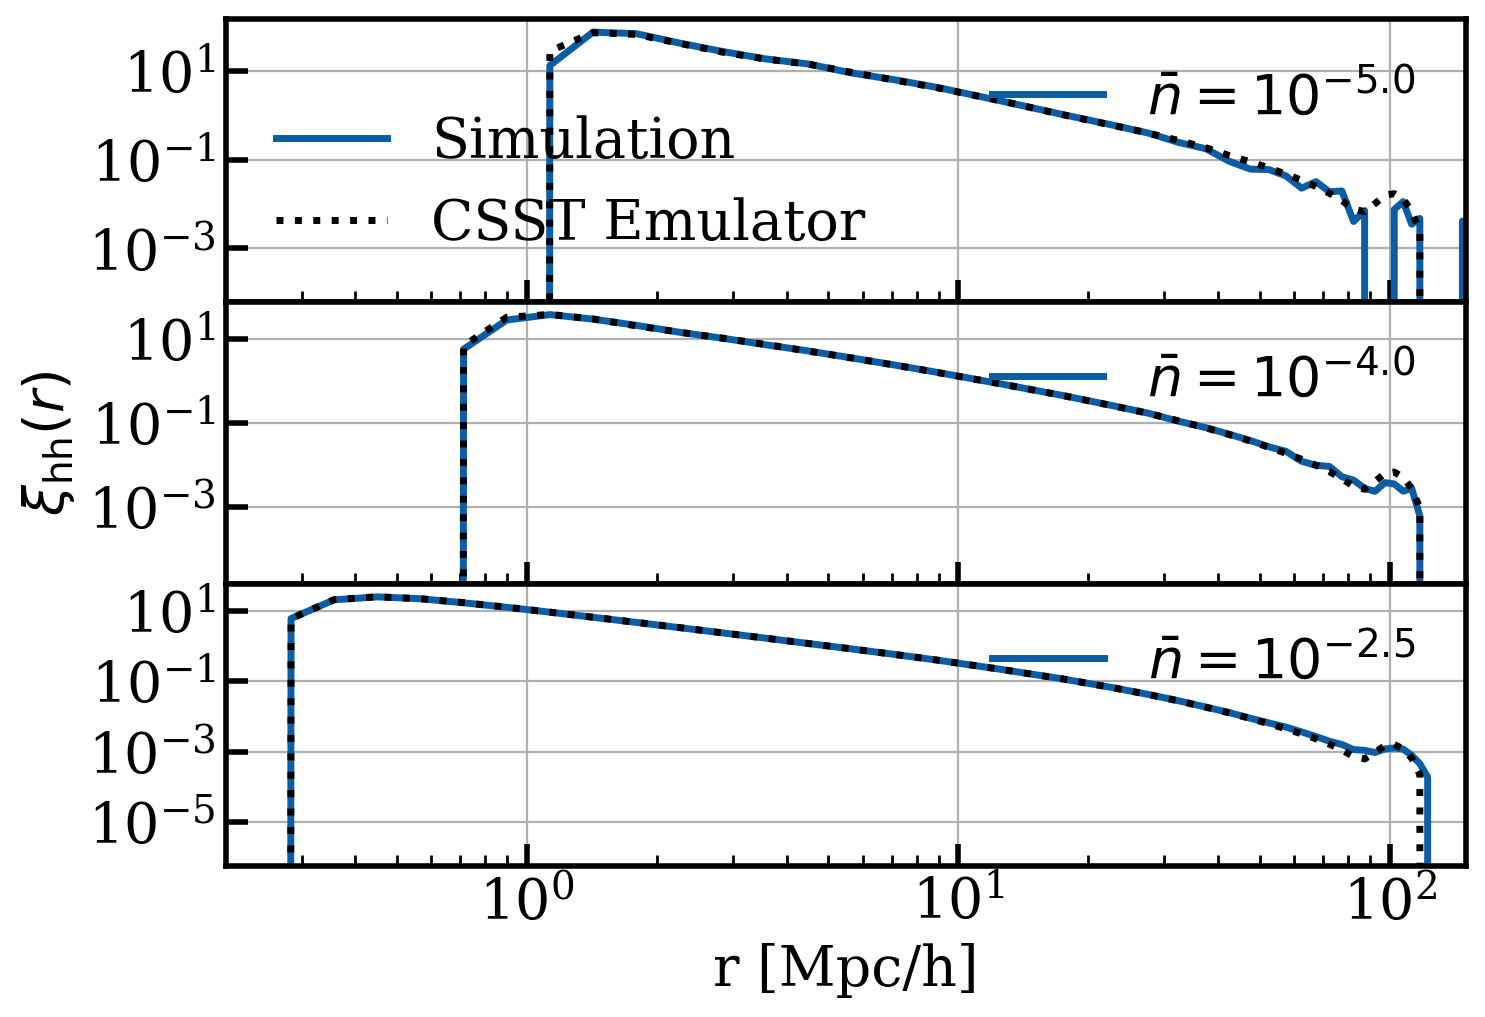

In [13]:
idensel = [0, 2, 5]
gridp   = plt.GridSpec(len(idensel), 1, wspace=0.0, hspace=0.0)
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        isim = idenlist[ii]
        l1, = plt.loglog(rmid,  xihh_sim[isim], ls='-', label=legstrs[ii])
        l2, = plt.loglog(rmid,  xihh_emu[0,ii], color='k', ls=":")
        leg1 = plt.legend(loc="upper right", ncol=1)
        if pind == 0:
            leg2 = plt.legend([l1,l2], ["Simulation", "CSST Emulator"], ncol=1)
            plt.gca().add_artist(leg1)
        # plt.ylim([0.8, 1.2])
        plt.xlim([2e-1, 150])
        plt.grid(True)
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hh}(r)$")
        

In [14]:
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 50, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2

xihm_sim = np.load("/Users/chenzhao/Desktop/mocktest/xihm_simu_n129_HybridNBin37_rockstar.npy")[0,8]
print(xihm_sim.shape, len(rmid))

xihm_emu = emu.get_xihm_lgnbar_threshold(r=rmid, z=redshift, lgden=lgdens)
print(xihm_emu.shape)

(13, 37) 37
(6, 1, 37)


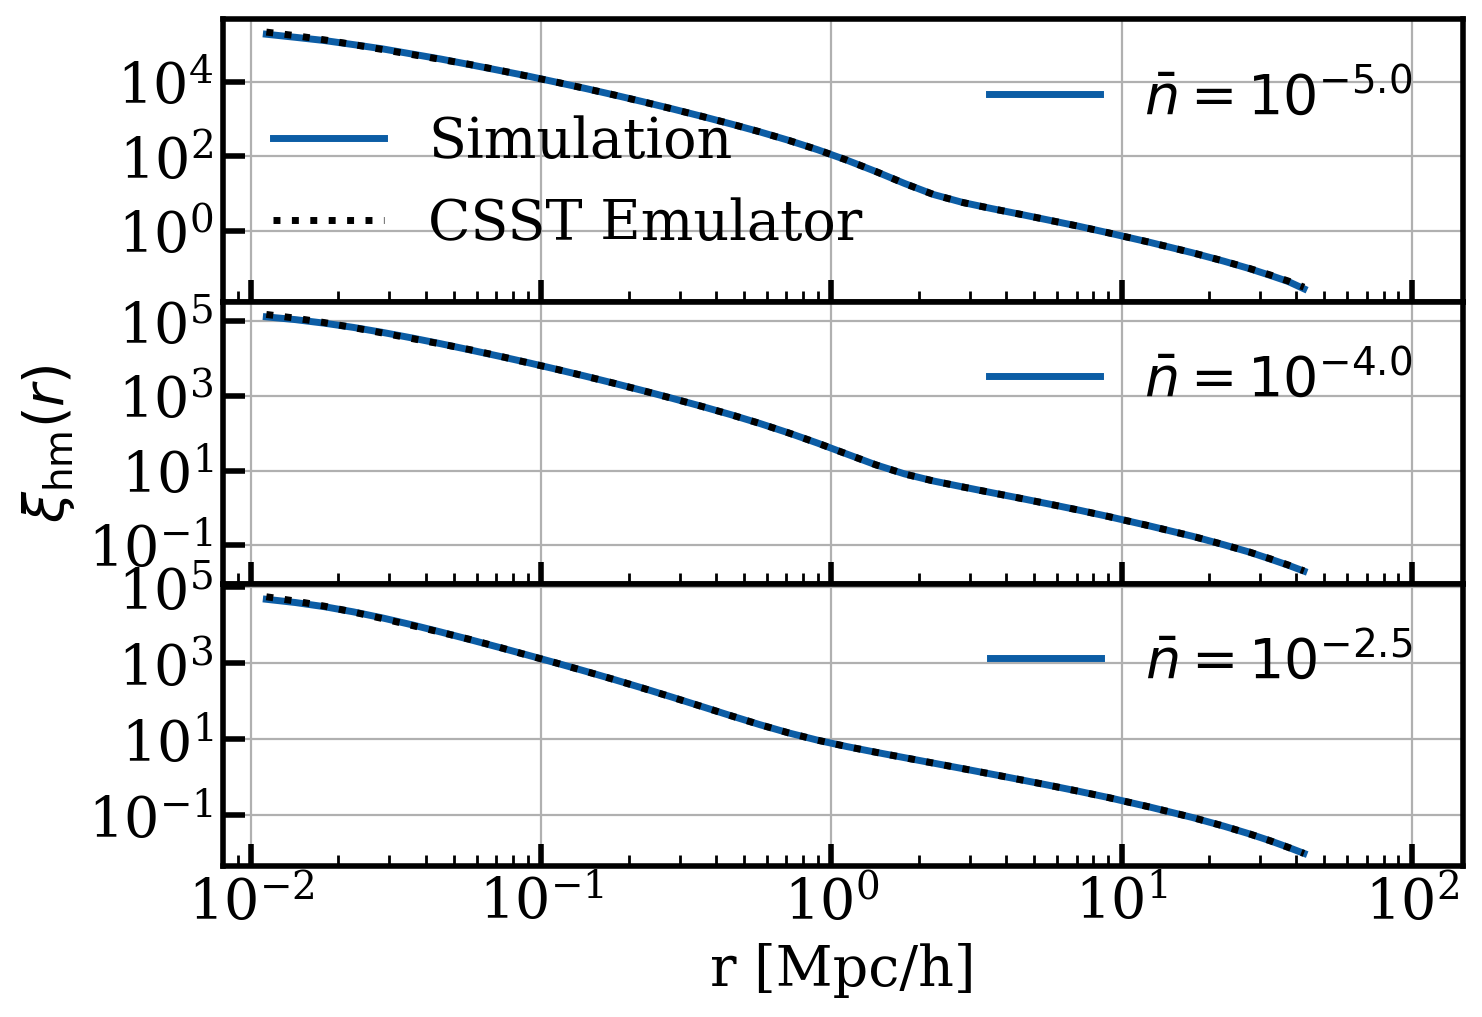

In [15]:
idensel = [0, 2, 5]
gridp   = plt.GridSpec(len(idensel), 1, wspace=0.0, hspace=0.0)
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        l1, = plt.loglog(rmid,  xihm_sim[7+ii], ls='-', label=legstrs[ii])
        l2, = plt.loglog(rmid,  xihm_emu[ii,0], color='k', ls=":")
        leg1 = plt.legend()
        if pind == 0:
            leg2 = plt.legend([l1,l2], ["Simulation", "CSST Emulator"], loc="lower left")
            plt.gca().add_artist(leg1)
        # plt.ylim([0.8, 1.2])
        plt.grid(True)
        plt.xlim([8e-3, 150])
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hm}(r)$")
        

In [16]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator
import numpy as np

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.048975
ns     = 0.9665
mnu    = 0.06
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.50

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=True)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1], 
                       np.arange(10, 500, 5)])
rmid  = rbins[:-1] + np.diff(rbins)/2

# M_arr  = np.array([6e12, 1e13, 5e13, 1e14, 1e15])
M_arr  = np.logspace(12, 16, 21)
zlists = [0.0, 0.5, 1.0, 1.5]

lgdens = np.linspace(-5.0, -2.5, 6)
xihm0 = emu.get_xihm_lgnbar_threshold(r=rmid, z=zlists, lgden=lgdens)
print(xihm0.shape)


Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [17]:
M_arr = np.array([1e13, 5e13, 1e14])
ktt  = np.logspace(-3, 1, 100)
lgden = np.log10(emu.get_Nhalo(z=[0.5], M=M_arr))
print(lgden.shape)
print(lgden[0])
t0 = emu.get_pkhm_lgnbar_threshold(z=0.5, k=ktt, lgden=lgden[0][::-1])
print(t0.shape)

(1, 3)
[-3.4188979  -4.36791885 -4.89344373]
(3, 1, 100)


In [18]:
# M_arr  = np.logspace(13, 15, 9)
M_arr = np.array([1e13, 5e13, 1e14])
ktt  = np.logspace(-3, 1, 100)
t2 = emu.get_pkhm_mass(z=[0.5], M=M_arr, k=ktt, massdef='RockstarM200m')
print(t2.shape)

(3, 1, 100)


(9, 3, 127)


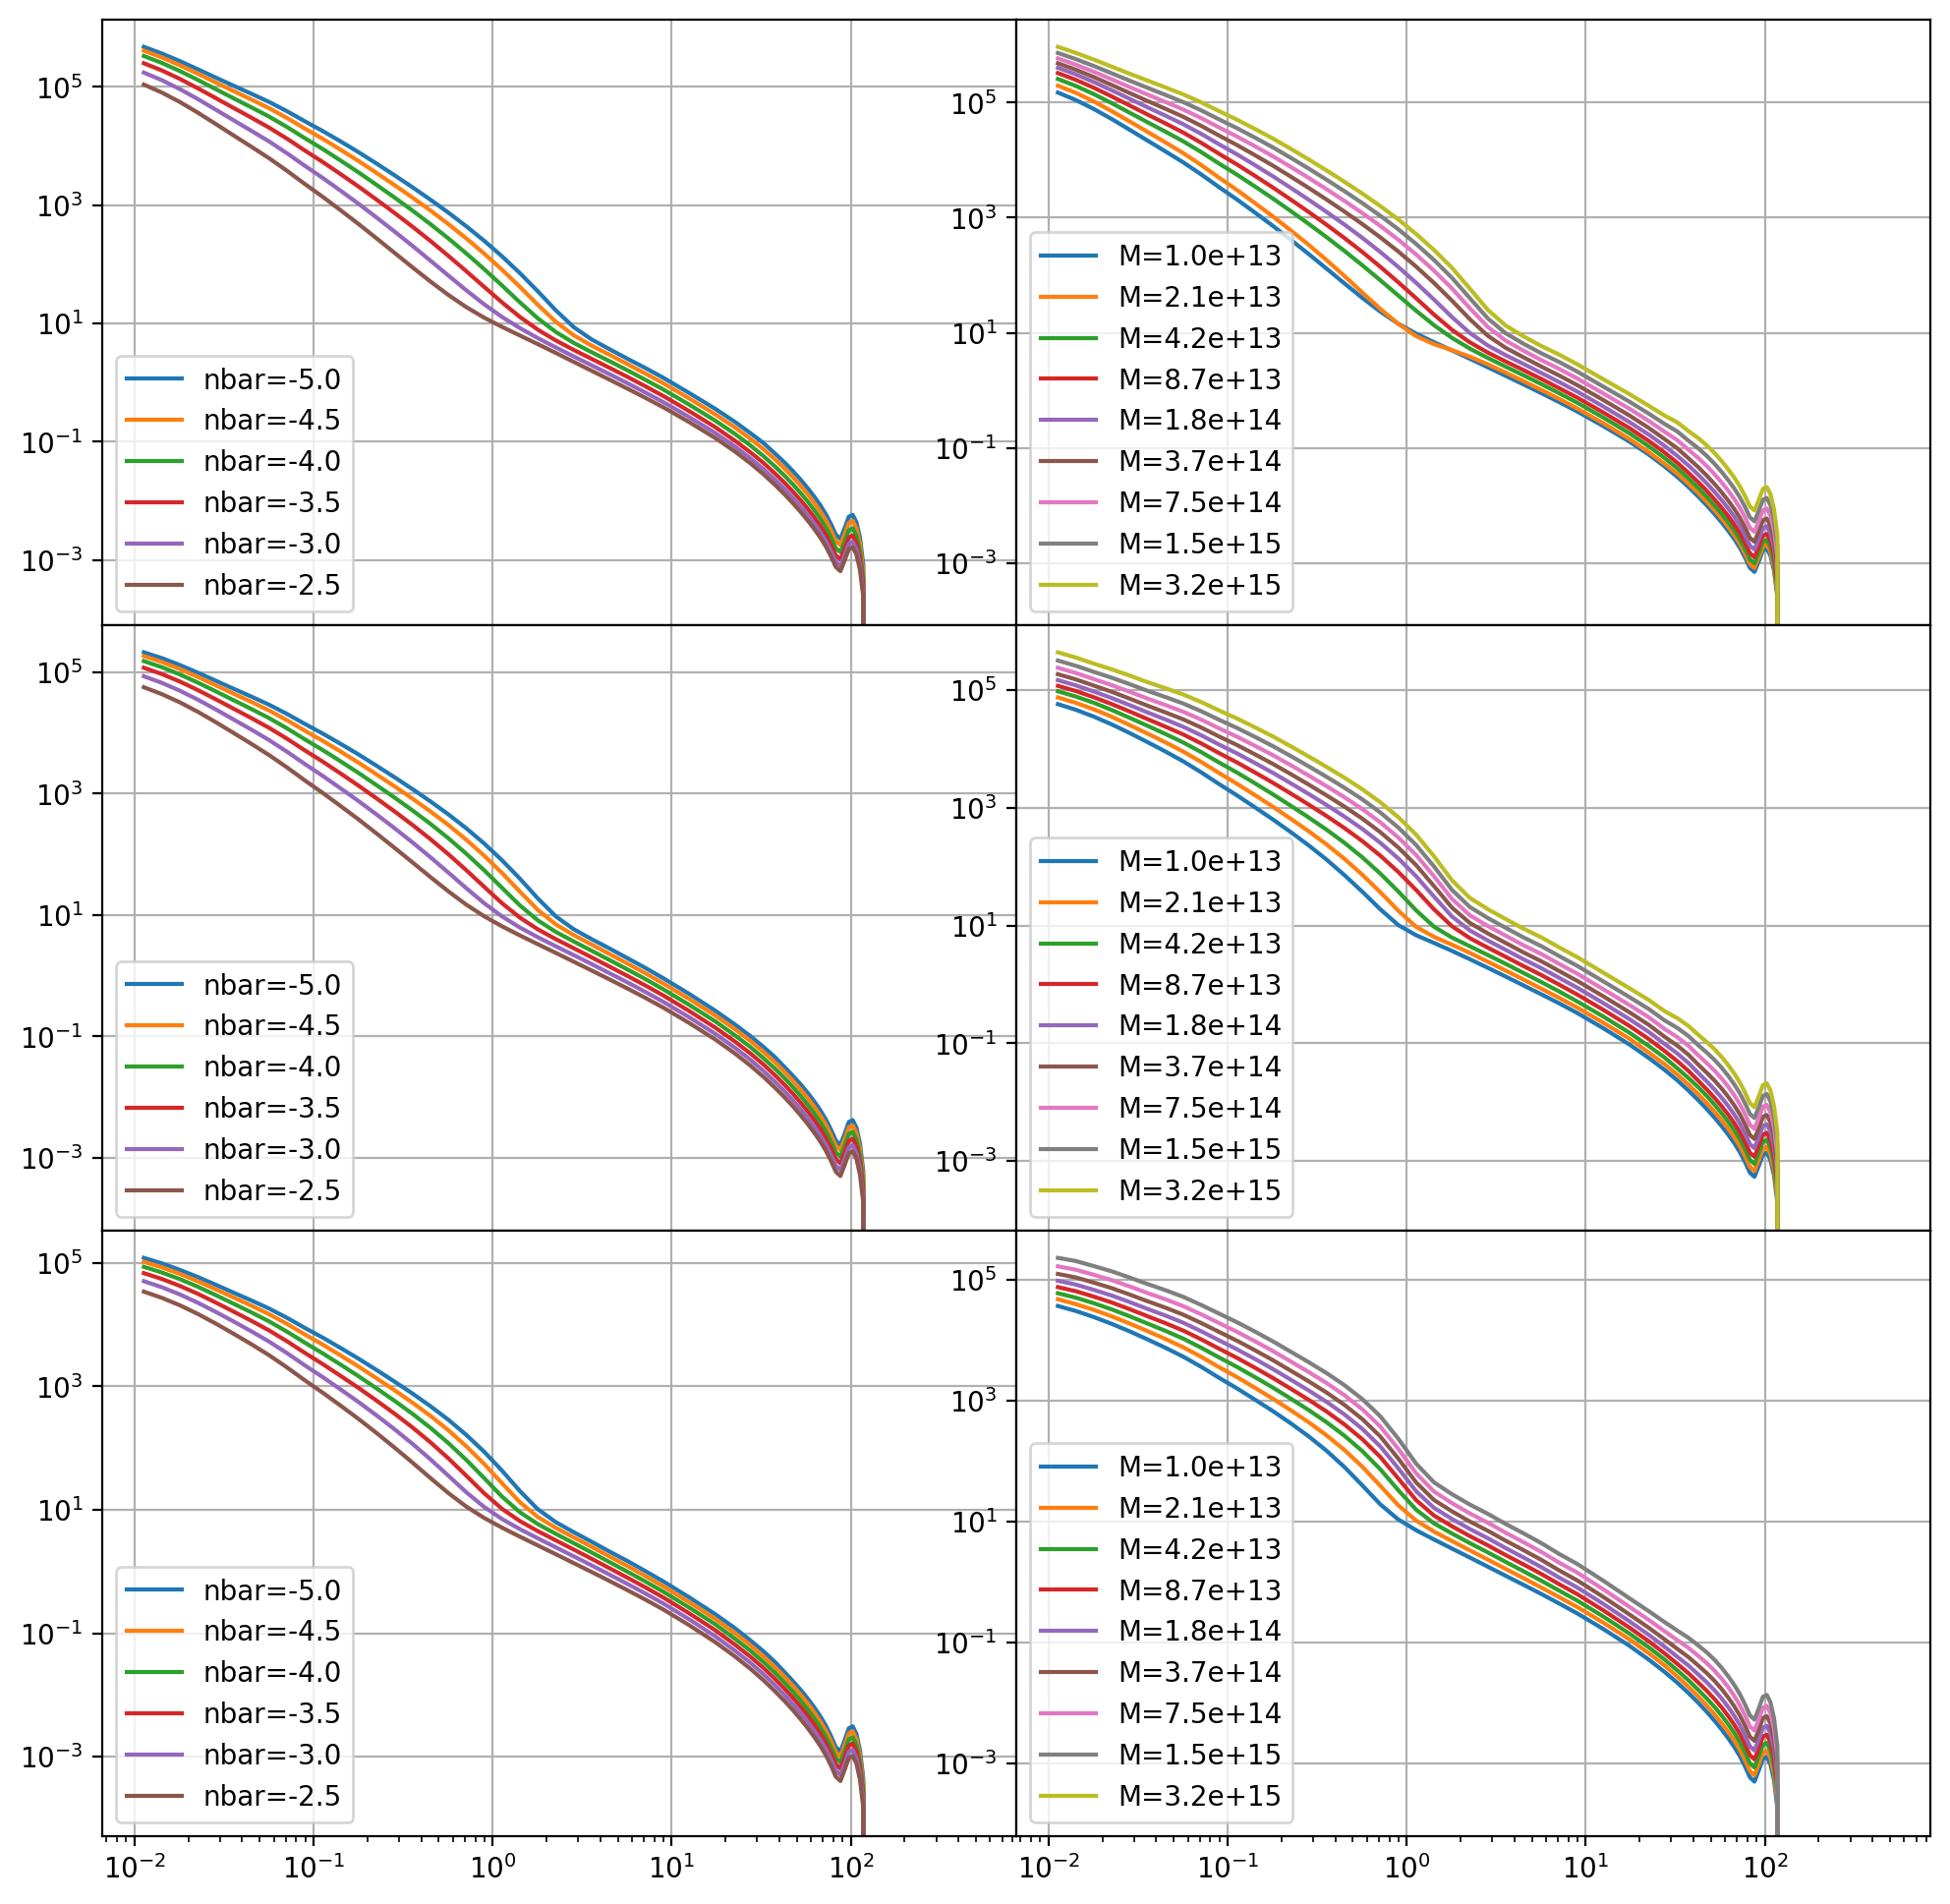

In [19]:
M_arr  = np.logspace(13, 15.5, 9)
z      = [0,1,2]
# M_arr = np.array([6e12, 1e13, 5e13, 1e14, 1e15])
xihm1 = emu.get_xihm_mass(z=z, r=rmid, M=M_arr)
print(xihm1.shape)
import matplotlib.pyplot as plt

gridp = plt.GridSpec(len(z), 2, wspace=0.0, hspace=0.0)
plt.figure(figsize=(12, 12))
for pind, zz in enumerate(z):
    plt.subplot(gridp[pind, 0])
    for ii in range(xihm0.shape[0]):
        plt.loglog(rmid, xihm0[ii,pind], label="nbar=%.1f"%(lgdens[ii]))
    plt.grid(True)
    plt.legend(loc="lower left")
    plt.subplot(gridp[pind, 1])
    for ii in range(xihm1.shape[0]):
        plt.loglog(rmid, xihm1[ii,pind], label="M=%.1e"%(M_arr[ii]))
    plt.grid(True)
    plt.legend(loc="lower left")


Loading Xihh emulator...
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir_bound emulator...
Using 129 training samples.
Loading the bhmNumBin_RockstarM200m emulator...
Using 129 training samples.
Loading the hNumBin_RockstarM200m emulator...
Using 129 training samples.
CPU times: user 2.53 s, sys: 55.2 ms, total: 2.59 s
Wall time: 1.26 s
(9, 9, 3, 127)


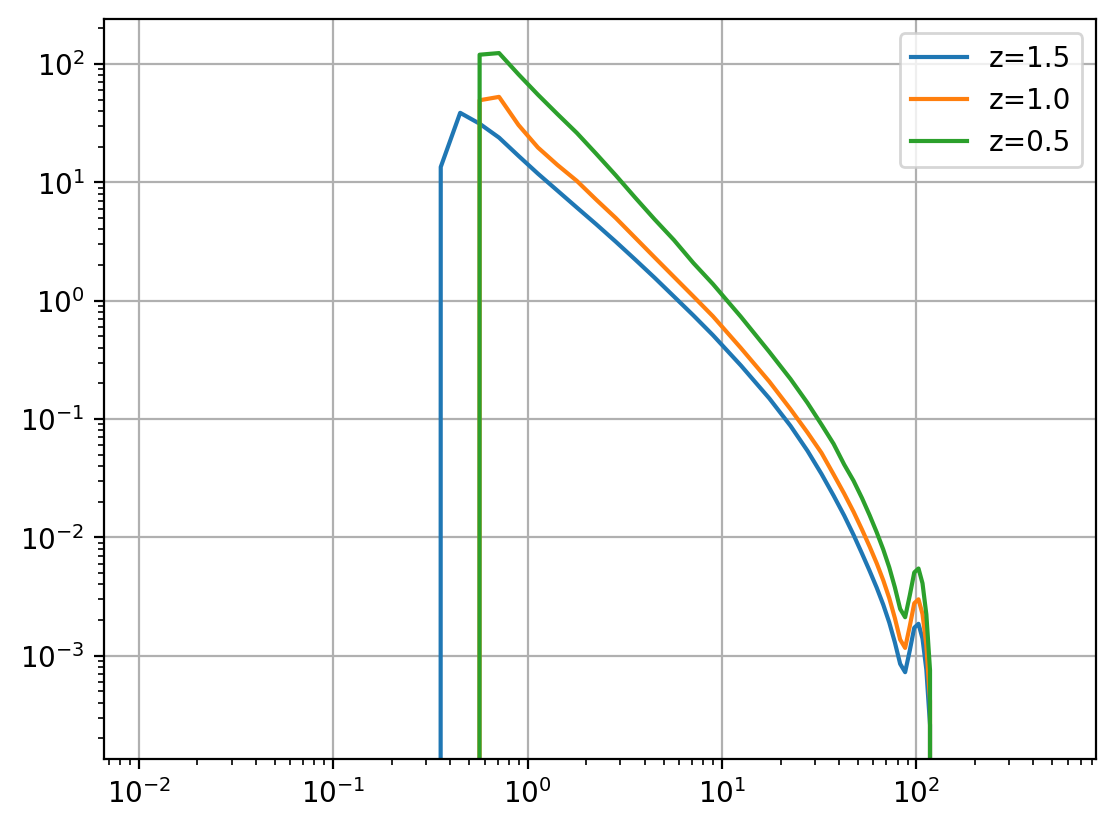

In [20]:

%time tt = emu.Xihh.get_xihh_mass(z=z, r=rmid, M1=M_arr, M2=M_arr)
print(tt.shape)
import matplotlib.pyplot as plt
for ii in range(tt.shape[2]):
    plt.loglog(rmid, tt[0,0,ii], label="z=%.1f"%(zlists[::-1][ii]))
plt.grid(True)
plt.legend()

In [21]:
lgden_arr = np.linspace(-5.0, -2.5, 6)
%time t0 = emu.Xihh.get_xihh_lgnbar_threshold(z=zlists, r=rmid, lgden1=lgden_arr, lgden2=lgden_arr)
print(t0.shape)

CPU times: user 227 ms, sys: 6.77 ms, total: 234 ms
Wall time: 240 ms
(6, 6, 4, 127)


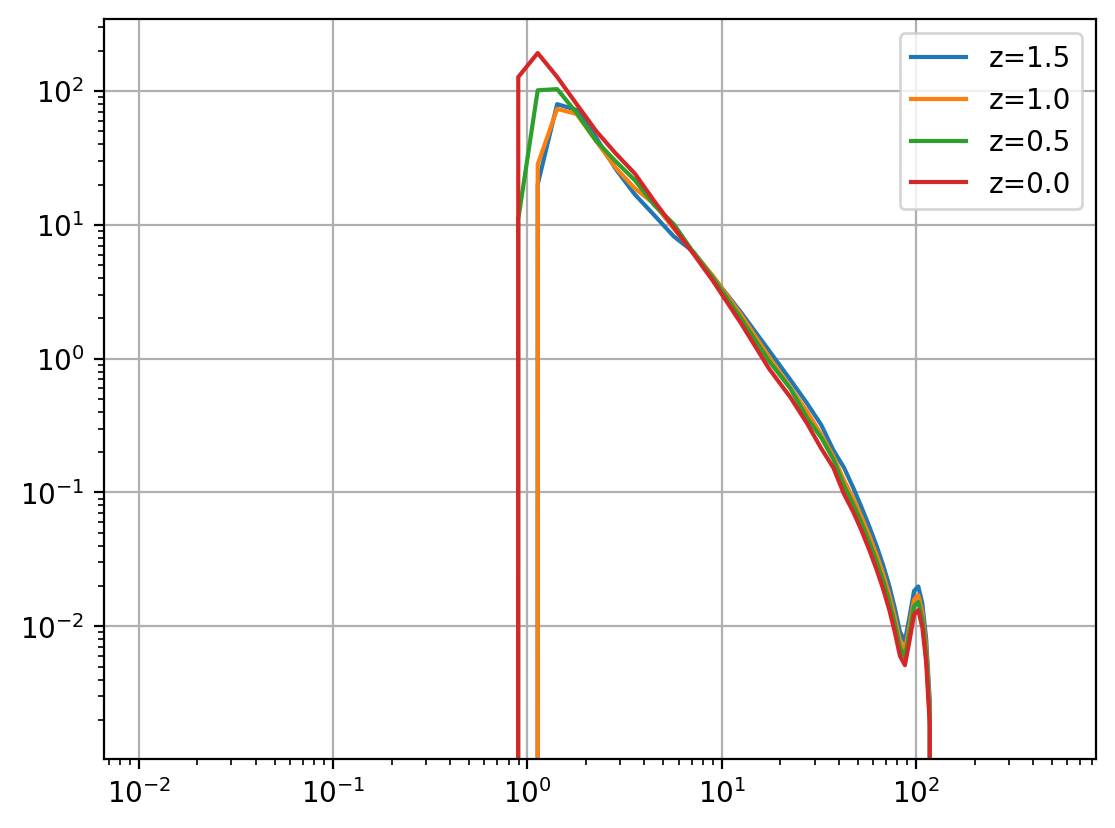

In [22]:
for ii in range(t0.shape[2]):
    plt.loglog(rmid, t0[0,0,ii], label="z=%.1f"%(zlists[::-1][ii]))
plt.legend()
plt.grid(True)